<h1 style="color:#ff4d4d; font-weight:bold; text-align:center;">
Prédiction du Prix des Courses de Taxi
</h1>

**Collaborateurs :** 
- Rayane DJEMA
- Jean-Baptiste CHEZE
- Alpha DIALLO



In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet

import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import shap

c:\Users\maserati\Desktop\Mosef_2025\projet_ml_jb_alpha_rayane\Predicting_Airline_Ticket_Prices\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# <span style="color:#1e90ff;">Abstract</span>

Ce projet vise à construire un modèle de prédiction du prix des courses de taxi à partir de différentes approches de modélisation. Après une préparation rigoureuse des données, plusieurs algorithmes sont entraînés, dont Elastic Net, Random Forest et XGBoost. Chaque modèle est optimisé via validation croisée puis évalué à l’aide de métriques standard telles que le RMSE, le MAE et le R².

L’objectif est d’identifier la méthode offrant les meilleures performances de généralisation. Une comparaison finale des métriques permet de déterminer le modèle le plus efficace et le plus robuste pour la prédiction des prix de course des Taxis de Chicago.


# <span style="color:#1e90ff;">Data</span>

Le jeu de données utilisé provient du portail officiel de la ville de Chicago : **[Taxi Trips (2024)](https://data.cityofchicago.org/Transportation/Taxi-Trips-2024-/ajtu-isnz/about_data)**.  
Il regroupe l’ensemble des courses de taxi enregistrées à partir de janvier 2024.



### <span style="color:#1e90ff;">Fetching the Data (Raw Data)</span>

In [2]:
df = pd.read_csv("../data/Taxi_Trips_(2024-)_20251120.csv",sep=",")

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\1583862138.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Taxi_Trips_(2024-)_20251120.csv",sep=",")


### <span style="color:#1e90ff;">Input (Raw Data)</span>

Dans cette section, nous analysons les données brutes juste après leur chargement.  
L'objectif est d'inspecter leur structure, identifier les problèmes potentiels (types incorrects, valeurs manquantes, anomalies), puis appliquer un premier preprocessing.


| Variable                       | Type     | Description                                                      |
|--------------------------------|----------|------------------------------------------------------------------|
| Trip ID                        | object   | Identifiant unique de la course                                 |
| Taxi ID                        | object   | Identifiant du taxi                                              |
| Trip Start Timestamp           | object   | Date et heure de début (arrondies pour confidentialité)         |
| Trip End Timestamp             | object   | Date et heure de fin                                             |
| Trip Seconds                   | object   | Durée de la course en secondes                                   |
| Trip Miles                     | object   | Distance parcourue en miles                                      |
| Pickup Census Tract            | float64  | Tract de recensement de prise en charge                         |
| Dropoff Census Tract           | float64  | Tract de recensement de dépose                                   |
| Pickup Community Area          | float64  | Zone (community area) de prise en charge                        |
| Dropoff Community Area         | float64  | Zone (community area) de dépose                                  |
| <span style="color:#ff4d4d;"><b>Fare</b></span>          | object   | **Variable cible (y)** : tarif de base payé par le client        |
| Tips                           | object   | Pourboires                                                        |
| Tolls                          | object   | Péages                                                            |
| Extras                         | object   | Frais additionnels                                                |
| Trip Total                     | object   | Montant total de la course (Fare + extras + tips)                |
| Payment Type                   | object   | Mode de paiement                                                  |
| Company                        | object   | Compagnie de taxi                                                 |
| Pickup Centroid Latitude       | float64  | Latitude du point de prise en charge                              |
| Pickup Centroid Longitude      | float64  | Longitude du point de prise en charge                             |
| Pickup Centroid Location       | object   | Coordonnées textuelles de prise en charge                        |
| Dropoff Centroid Latitude      | float64  | Latitude du point de dépose                                       |
| Dropoff Centroid Longitude     | float64  | Longitude du point de dépose                                      |
| Dropoff Centroid Location      | object   | Coordonnées textuelles de dépose                                  |


### <span style="color:#1e90ff;">Preprocessing  (Raw Data)</span>


In [3]:
print(f"-Le Nombre de colonnes est de : {df.shape[1]}\n-Le nombre de lignes est de {df.shape[0]}")

-Le Nombre de colonnes est de : 23
-Le nombre de lignes est de 12233748


In [4]:
df.isna().sum().sort_values(ascending=False)

Dropoff Census Tract          6988028
Pickup Census Tract           6820182
Dropoff Community Area        1112901
Dropoff Centroid Longitude    1044112
Dropoff Centroid  Location    1044112
Dropoff Centroid Latitude     1044112
Pickup Community Area          340545
Pickup Centroid Location       334109
Pickup Centroid Latitude       334109
Pickup Centroid Longitude      334109
Trip Total                      28149
Fare                            28149
Extras                          28149
Tolls                           28149
Tips                            28149
Trip Seconds                     2313
Trip End Timestamp                132
Trip Miles                        101
Taxi ID                            11
Trip ID                             0
Trip Start Timestamp                0
Payment Type                        0
Company                             0
dtype: int64

In [5]:
num_price_cols = ["Trip Total", "Fare", "Tips", "Tolls", "Extras"]

for col in num_price_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)   # retirer les virgules thousands
        .str.replace("$", "", regex=False)   # retirer éventuels $
        .str.strip()                         # retirer espaces
        .replace("", pd.NA)                  # convertir vide -> NA
    )

    # Conversion finale en float
    df[col] = pd.to_numeric(df[col], errors="coerce")

Nettoyage de Trip Total...
Nettoyage de Fare...
Nettoyage de Tips...
Nettoyage de Tolls...
Nettoyage de Extras...


In [6]:
df[num_price_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Trip Total  float64
 1   Fare        float64
 2   Tips        float64
 3   Tolls       float64
 4   Extras      float64
dtypes: float64(5)
memory usage: 466.7 MB


In [7]:
df[num_price_cols].head(3)

,Trip Total,Fare,Tips,Tolls,Extras
0,17.67,17.17,0.00,0.0,0.0
1,13.00,12.50,0.00,0.0,0.0
2,58.65,44.50,7.65,0.0,6.0


In [8]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df[num_price_cols].describe()

,Trip Total,Fare,Tips,Tolls,Extras
count,12205599.000,12205599.000,12205599.000,12205599.000,12205599.000
mean,27.970,22.781,2.839,0.031,2.087
std,37.085,32.549,4.272,4.105,9.169
min,0.000,0.000,0.000,0.000,0.000
25%,10.250,8.500,0.000,0.000,0.000
50%,18.600,15.650,0.000,0.000,0.000
75%,42.310,34.250,4.000,0.000,2.000
max,9999.750,9999.750,400.000,5550.000,5559.500


- Les variables financières (Trip Total, Fare, Tips, Extras, Tolls) ainsi que les variables de distance (Trip Miles) et de durée (Trip Seconds) étaient initialement au format texte, à cause de symboles comme "$" ou ",".

- Ci-dessus nous convertissons chacune de ces colonnes en "float" afin de pouvoir effectuer des calculs et des statistiques.  

In [9]:
num_trip_cols = ["Trip Miles", "Trip Seconds"]

for col in num_trip_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

Nettoyage de Trip Miles...
Nettoyage de Trip Seconds...


In [10]:
df[num_trip_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Trip Miles    float64
 1   Trip Seconds  float64
dtypes: float64(2)
memory usage: 186.7 MB


In [11]:
df[num_trip_cols].describe()

,Trip Miles,Trip Seconds
count,12233647.000,12231435.000
mean,6.700,1250.370
std,7.705,1630.032
min,0.000,0.000
25%,1.070,480.000
50%,3.220,926.000
75%,11.800,1696.000
max,3397.800,86400.000


In [12]:
df[num_trip_cols].head()

,Trip Miles,Trip Seconds
0,4.770,1015.000
1,4.120,595.000
2,17.630,1853.000
3,15.350,1489.000
4,3.350,700.000


In [13]:
geo_cols = ["Pickup Community Area", "Dropoff Community Area"]

for col in geo_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False) 
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

Nettoyage de Pickup Community Area...
Nettoyage de Dropoff Community Area...


In [14]:
geo_cols = ["Pickup Community Area", "Dropoff Community Area"]

for col in geo_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)  
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

Nettoyage de Pickup Community Area...
Nettoyage de Dropoff Community Area...


###  Nettoyage des zones géographiques simplifiées (Community Areas)

Les colonnes Pickup Community Area et Dropoff Community Area représentent 
les zones administratives de Chicago (1 à 77) où commencent et se terminent les trajets.  
Ces deux variables sont essentielles pour capturer l’effet géographique sur le prix des courses, 
tout en évitant la complexité excessive des coordonnées GPS ou des Census Tracts.

Cependant, plusieurs problèmes étaient présents :
- des valeurs manquantes importantes (environ 340k pour pickup et 1.1M pour dropoff),
- des formats incohérents (valeurs sous forme de texte, parfois avec des virgules),
- des zones inconnues lorsque le taxi sort de Chicago ou lorsque la donnée est anonymisée.

Dans cette étape, je :
1. Nettoie le format (strip, suppression de caractères parasites) ;
2. Convertis les colonnes en type numérique float64 ;
3. Remplace les valeurs manquantes par -1, une nouvelle modalité indiquant 
   une zone géographique inconnue.

Cette approche permet de conserver tous les trajets tout en rendant les données cohérentes 
et exploitables pour l'analyse et la modélisation.


In [15]:
df[geo_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Pickup Community Area   float64
 1   Dropoff Community Area  float64
dtypes: float64(2)
memory usage: 186.7 MB


In [16]:
df[geo_cols].describe()

,Pickup Community Area,Dropoff Community Area
count,11893203.000,11120847.000
mean,35.545,26.097
std,26.144,20.598
min,1.000,1.000
25%,8.000,8.000
50%,32.000,28.000
75%,56.000,32.000
max,77.000,77.000


In [17]:
df[geo_cols].head()

,Pickup Community Area,Dropoff Community Area
0,32.000,24.000
1,22.000,16.000
2,76.000,32.000
3,32.000,9.000
4,28.000,32.000


In [18]:
date_cols = ["Trip Start Timestamp", "Trip End Timestamp"]

for col in date_cols:
    print(f"Conversion de {col} en datetime...")
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].info()
df[date_cols].head()

Conversion de Trip Start Timestamp en datetime...


C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\2773000789.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


Conversion de Trip End Timestamp en datetime...


C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\2773000789.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Trip Start Timestamp  datetime64[ns]
 1   Trip End Timestamp    datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 186.7 MB


,Trip Start Timestamp,Trip End Timestamp
0,2025-11-01,2025-11-01 00:15:00
1,2025-11-01,2025-11-01 00:00:00
2,2025-11-01,2025-11-01 00:30:00
3,2025-11-01,2025-11-01 00:30:00
4,2025-11-01,2025-11-01 00:00:00


**Conversion des colonnes temporelles en format datetime**

Les colonnes Trip Start Timestamp et Trip End Timestamp sont fournies dans le dataset
au format texte (string). Pour pouvoir analyser correctement la dimension temporelle des trajets 
et créer de futures variables (heure, jour de la semaine, période de la journée, etc.), 
je convertis ces deux colonnes en type datetime64.

Cette conversion permet :
- d’extraire facilement des informations temporelles (heure, jour, mois, année),
- d'étudier les heures de pointe et les comportements selon les périodes de la journée,
- de vérifier la cohérence entre la durée enregistrée (Trip Seconds) et la différence entre les timestamps.

 Les rares valeurs manquantes seront ensuite traitées lors du nettoyage.


In [19]:
cat_cols = ["Payment Type", "Company"]

for col in cat_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()          # enlever espaces au début/fin
    )
    # On remplace les valeurs "nan" texte par NA réelle
    df[col] = df[col].replace(["nan", "NaN", "None", ""], pd.NA)
    df[col] = df[col].astype("category")

df[cat_cols].info()
for col in cat_cols:
    print(f"\nValeurs les plus fréquentes pour {col} :")
    print(df[col].value_counts(dropna=False).head(10))

Nettoyage de Payment Type...
Nettoyage de Company...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column        Dtype   
---  ------        -----   
 0   Payment Type  category
 1   Company       category
dtypes: category(2)
memory usage: 23.3 MB

Valeurs les plus fréquentes pour Payment Type :
Payment Type
Credit Card    4638710
Cash           3233359
Mobile         2438598
Prcard         1419565
Unknown         462386
No Charge        34028
Dispute           7062
Prepaid             40
Name: count, dtype: int64

Valeurs les plus fréquentes pour Company :
Company
Flash Cab                            2553158
Taxi Affiliation Services            1666116
Taxicab Insurance Agency Llc         1417640
Sun Taxi                             1327798
City Service                         1196014
Chicago Independents                  746495
5 Star Taxi                           602775
Blue Ribbon Taxi Association          51

**Nettoyage des variables catégorielles (Payment Type, Company)**

Les colonnes catégorielles contenaient des espaces parasites, des chaînes 'nan' et d'autres incohérences.  
Nous nettoyons ces valeurs (strip, remplacement des faux NA) puis nous convertissons les colonnes en category, ce qui :

- réduit la mémoire utilisée,
- prépare les données pour les futures étapes d’encodage,
- facilite l’analyse des distributions de modalités.

In [20]:
for col in df.columns:
    print(f"'{col}'")

'Trip ID'
'Taxi ID'
'Trip Start Timestamp'
'Trip End Timestamp'
'Trip Seconds'
'Trip Miles'
'Pickup Census Tract'
'Dropoff Census Tract'
'Pickup Community Area'
'Dropoff Community Area'
'Fare'
'Tips'
'Tolls'
'Extras'
'Trip Total'
'Payment Type'
'Company'
'Pickup Centroid Latitude'
'Pickup Centroid Longitude'
'Pickup Centroid Location'
'Dropoff Centroid Latitude'
'Dropoff Centroid Longitude'
'Dropoff Centroid  Location'


In [21]:
cols_to_drop = [
    "Pickup Census Tract",
    "Dropoff Census Tract",
    "Pickup Centroid Latitude",
    "Pickup Centroid Longitude",
    "Pickup Centroid Location",
    "Dropoff Centroid Latitude",
    "Dropoff Centroid Longitude",
    "Dropoff Centroid  Location"   # double espace ici par exemple
]

df = df.drop(columns=cols_to_drop,axis=1)


**Suppression des colonnes géographiques détaillées**

Le dataset contient plusieurs colonnes géographiques très précises 
(Census Tract, Centroid Latitude/Longitude, Centroid Location).  
Ces variables posent plusieurs problèmes :

- elles contiennent un très grand nombre de valeurs manquantes 
- elles sont souvent vides pour les trajets hors de Chicago 
- leur niveau de précision (tract, centroid) est trop élevé pour notre objectif 
- elles n'apportent pas d'information utile supplémentaire par rapport 
  aux variables plus simples comme Pickup Community Area et Dropoff Community Area.

Dans cette étape, je supprime donc ces colonnes afin de :
- réduire la taille du dataset,
- éliminer du bruit inutile,
- simplifier l'analyse exploratoire,
- et garder uniquement les informations géographiques réellement pertinentes.

Les Community Areas seront conservées, car elles décrivent les zones de prise en charge 
et de dépose de manière suffisamment informative et cohérente pour la modélisation.


In [22]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 15 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Trip ID                 object        
 1   Taxi ID                 object        
 2   Trip Start Timestamp    datetime64[ns]
 3   Trip End Timestamp      datetime64[ns]
 4   Trip Seconds            float64       
 5   Trip Miles              float64       
 6   Pickup Community Area   float64       
 7   Dropoff Community Area  float64       
 8   Fare                    float64       
 9   Tips                    float64       
 10  Tolls                   float64       
 11  Extras                  float64       
 12  Trip Total              float64       
 13  Payment Type            category      
 14  Company                 category      
dtypes: category(2), datetime64[ns](2), float64(9), object(2)
memory usage: 1.2+ GB


(12233748, 15)

In [23]:
df.isna().sum().sort_values(ascending=False)

Dropoff Community Area    1112901
Pickup Community Area      340545
Trip Total                  28149
Tolls                       28149
Tips                        28149
Fare                        28149
Extras                      28149
Trip Seconds                 2313
Trip End Timestamp            132
Trip Miles                    101
Taxi ID                        11
Trip ID                         0
Trip Start Timestamp            0
Payment Type                    0
Company                         0
dtype: int64

In [24]:
df = df.dropna(subset=[
    "Trip Total",
    "Trip Miles",
    "Trip Seconds",
    "Fare",
    "Tips",
    "Tolls",
    "Extras"
])

In [25]:
df["Pickup Community Area"] = df["Pickup Community Area"].fillna(-1)
df["Dropoff Community Area"] = df["Dropoff Community Area"].fillna(-1)

- Dans cette étape, nous traitons les valeurs manquantes des variables importantes.

- Pour les colonnes liées au prix (Trip Total, Fare, Tips, Tolls, Extras) ainsi que les colonnes de distance et de durée (Trip Miles, Trip Seconds), les valeurs manquantes représentent moins de 0,3 % du dataset. Comme ces variables sont essentielles pour la modélisation et qu'une imputation menera à des resultats moins fiables nous préférons de  supprimer ces lignes.

- Pour les colonnes géographiques simples (Pickup Community Area et Dropoff Community Area), les valeurs manquantes correspondent principalement à des trajets réalisés hors Chicago ou à des zones anonymisées. Plutôt que de supprimer plus d’un million de lignes, nous imputons ces valeurs manquantes avec une nouvelle catégorie –1, représentant une zone inconnue ("Unknown Area").

- Cette approche permet :
  - de conserver un maximum de données,
  - d’éviter de perdre des trajets valides,
  - de préserver une information exploitable pour la modélisation.


In [26]:
df.isna().sum().sort_values(ascending=False)

Taxi ID                   11
Trip ID                    0
Trip Start Timestamp       0
Trip End Timestamp         0
Trip Seconds               0
Trip Miles                 0
Pickup Community Area      0
Dropoff Community Area     0
Fare                       0
Tips                       0
Tolls                      0
Extras                     0
Trip Total                 0
Payment Type               0
Company                    0
dtype: int64

**Regardons s'il existe des doublons :**

In [27]:
df.duplicated().sum()

np.int64(0)

**On enregistre la premiere version de la base**

# <span style="color:#1e90ff;">Analyse Exploratoire (EDA)</span>

In [28]:
df.to_csv("../data/df_taxi_v1.csv")

In [29]:
df = pd.read_csv("../data/df_taxi_v1.csv")

| Variable                       | Description synthétique |
|--------------------------------|--------------------------|
| Trip ID                        | Identifiant unique de la course. |
| Taxi ID                        | Identifiant anonymisé du taxi (cohérent, mais ne correspond pas au vrai medallion). |
| Trip Start Timestamp           | Date et heure de début de la course (arrondie au quart d’heure). |
| Trip End Timestamp             | Date et heure de fin de la course. |
| Trip Seconds                   | Durée totale de la course en secondes. |
| Trip Miles                     | Distance de la course en miles. |
| Pickup Census Tract            | Zone de recensement (census tract) où le passager est monté, si disponible. |
| Dropoff Census Tract           | Zone de recensement où le passager est descendu, si disponible. |
| Pickup Community Area          | Code de la communauté de Chicago où la prise en charge a eu lieu. |
| Dropoff Community Area         | Code de la communauté où la dépose a eu lieu. |
| Fare                           | Tarif de base de la course (ne comprend ni les pourboires, ni les péages, ni les extras). |
| Tips                           | Montant des pourboires laissés par le passager. |
| Tolls                          | Montant des péages facturés pendant la course. |
| Extras                         | Frais supplémentaires (ex. surcharge carburant, surcharge aéroport). |
| Trip Total                     | Montant total payé par le passager (Fare + Tips + Tolls + Extras). |
| Payment Type                   | Mode de paiement utilisé (espèces, carte bancaire, etc.). |
| Company                        | Nom de la compagnie de taxi ayant réalisé la course. |
| Pickup Centroid Latitude       | Latitude du centroïde de la zone de prise en charge. |
| Pickup Centroid Longitude      | Longitude du centroïde de la zone de prise en charge. |
| Pickup Centroid Location       | Coordonnées combinées (point géographique) de la prise en charge. |
| Dropoff Centroid Latitude      | Latitude du centroïde de la zone de dépose. |
| Dropoff Centroid Longitude     | Longitude du centroïde de la zone de dépose. |
| Dropoff Centroid Location      | Coordonnées combinées (point géographique) de la dépose. |


In [30]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12204111 entries, 0 to 12204110
Data columns (total 16 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Unnamed: 0              int64  
 1   Trip ID                 object 
 2   Taxi ID                 object 
 3   Trip Start Timestamp    object 
 4   Trip End Timestamp      object 
 5   Trip Seconds            float64
 6   Trip Miles              float64
 7   Pickup Community Area   float64
 8   Dropoff Community Area  float64
 9   Fare                    float64
 10  Tips                    float64
 11  Tolls                   float64
 12  Extras                  float64
 13  Trip Total              float64
 14  Payment Type            object 
 15  Company                 object 
dtypes: float64(9), int64(1), object(6)
memory usage: 1.5+ GB


In [31]:
print(f"-Le nombre de ligne est de : {df.shape[1]}\n-Le nombre de colonnes est de : {df.shape[0]}")

-Le nombre de ligne est de : 16
-Le nombre de colonnes est de : 12204111



### <span style="color:#1e90ff;">Analyse temporelle</span>

On mets nos variables en datetime pour que l'analyse temporelle soit possible

In [32]:
df["Trip Start Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])
df["Trip End Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])

# Création des variables dérivées
df["start_hour"] = df["Trip Start Timestamp"].dt.hour
df["start_weekday"] = df["Trip Start Timestamp"].dt.weekday      # 0 = lundi, 6 = dimanche
df["start_month"] = df["Trip Start Timestamp"].dt.month
df["start_date"] = df["Trip Start Timestamp"].dt.date


# Week-end (1 si samedi/dimanche, 0 sinon)
df["is_weekend"] = df["start_weekday"].isin([5, 6]).astype(int)

df["period_of_day"] = pd.cut(
    df["start_hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Nuit", "Matin", "Après-midi", "Soir"],
    right=False
)

In [33]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

**Distribution des heures :**

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\502543016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


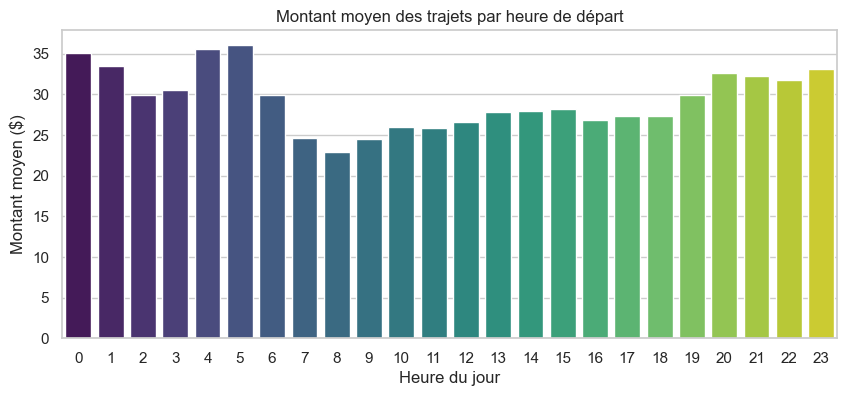

In [34]:
plt.figure(figsize=(10,4))

sns.barplot(
    x="start_hour",
    y="Trip Total",
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette="viridis"
)

plt.title("Montant moyen des trajets par heure de départ")
plt.xlabel("Heure du jour")
plt.ylabel("Montant moyen ($)")
plt.show()

L’ajout des variables hour_sin et hour_cos est particulièrement pertinent pour la prédiction du prix des courses de taxi, car l’heure de départ est une variable cyclique qui influence fortement les tarifs en fonction des variations de demande et de trafic au cours de la journée. Ces deux transformations permettent de représenter correctement la continuité du cycle 24h (où 23h est proche de 0h), ce qu’un modèle linéaire ne peut pas capturer avec l’heure brute. Par ailleurs, la variable binaire is_night permet d’isoler l’effet spécifique de la nuit, période durant laquelle les prix présentent souvent un comportement distinct (majorations, moindre disponibilité des chauffeurs, trajectoires plus rapides ou plus coûteuses). L’ensemble de ces variables enrichit donc la capacité du modèle à appréhender les variations journalières du prix et améliore la précision des prédictions.

In [35]:
df["hour_sin"] = np.sin(2 * np.pi * df["start_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["start_hour"] / 24)
df["is_night"] = df["start_hour"].isin([22,23,0,1,2,3,4,5,6]).astype(int)

**Jours de la semaine :**

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\774272280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


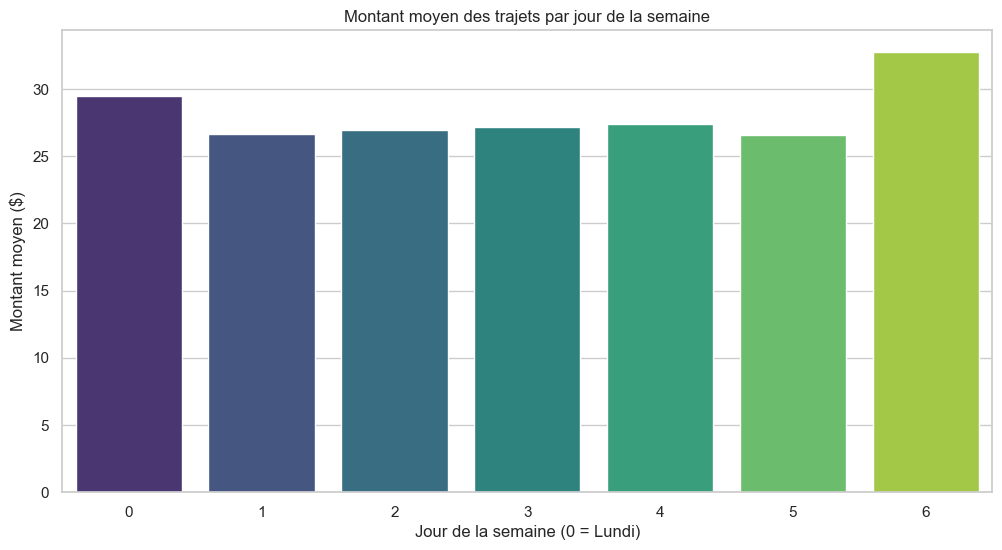

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="start_weekday",
    y="Trip Total",
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette="viridis"  
)

plt.title("Montant moyen des trajets par jour de la semaine")
plt.xlabel("Jour de la semaine (0 = Lundi)")
plt.ylabel("Montant moyen ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()

Les montants moyens varient selon le jour de la semaine. Le lundi (0) et surtout le dimanche (6) affichent les montants les plus élevés, tandis que les mardi–vendredi restent dans une plage plus basse et relativement stable. Le dimanche se démarque nettement comme le jour le plus cher. Cette variation montre que le jour de la semaine influence le prix des trajets, ce qui en fait une variable pertinente à intégrer dans ton modèle de prédiction.

Si la variable weekday est redondante ou n’apporte aucune information supplémentaire par rapport aux autres variables (comme la distance, la durée et l’heure), l’Elastic Net la supprimera automatiquement en ramenant ses coefficients à zéro grâce à la pénalisation L1.

**Week end vs Semaine**

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\405166784.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


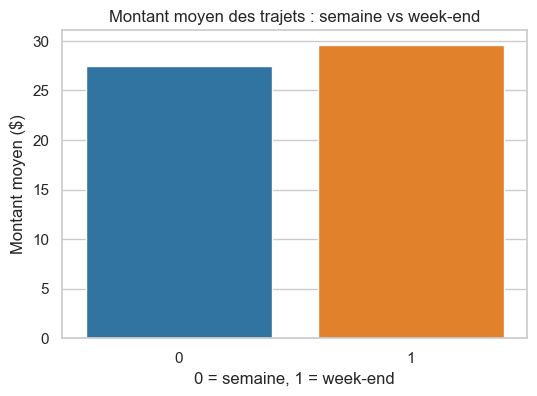

In [37]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="is_weekend",
    y="Trip Total",
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette={"0": "#1f77b4", "1": "#ff7f0e"}
)


plt.title("Montant moyen des trajets : semaine vs week-end")
plt.xlabel("0 = semaine, 1 = week-end")
plt.ylabel("Montant moyen ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()

Les trajets effectués le week-end sont en moyenne légèrement plus chers que ceux de la semaine. Cette différence, bien que modérée, indique que le week-end influence le montant des courses, ce qui en fait une variable pertinente à intégrer dans le modèle de prédiction.

**Heatmap Jour x Heure :**

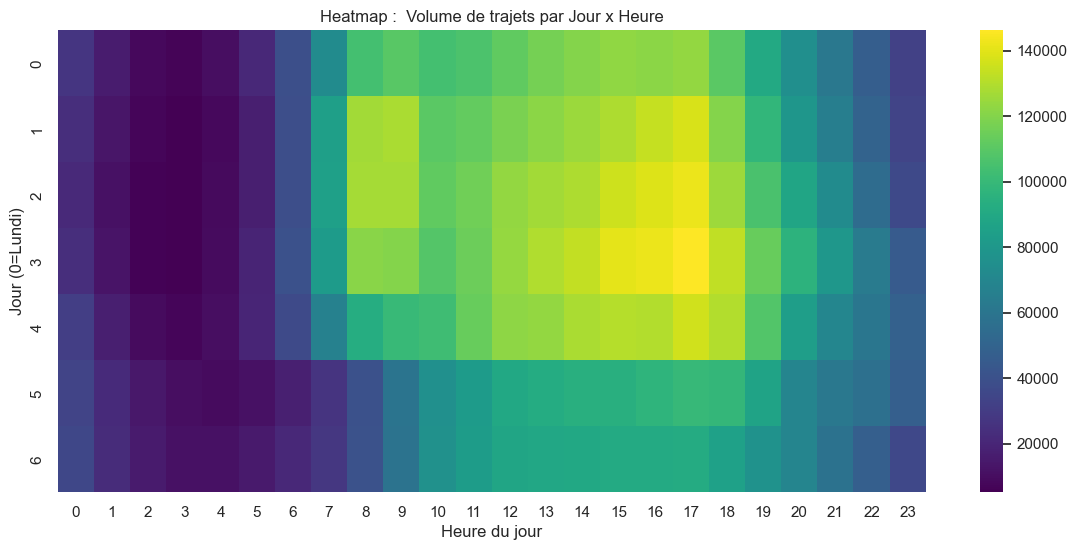

In [38]:
pivot_jour_heure = df.pivot_table(
    index="start_weekday",
    columns="start_hour",
    values="Trip ID",
    aggfunc="count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_jour_heure, cmap="viridis")
plt.title("Heatmap :  Volume de trajets par Jour x Heure")
plt.xlabel("Heure du jour")
plt.ylabel("Jour (0=Lundi)")
plt.show()

- Le volume de trajets présente une structure temporelle très marquée : l’activité est faible entre minuit et 5h, augmente rapidement à partir de 7h et atteint son maximum en fin de matinée et en fin d’après-midi.
- La même dynamique se répète du lundi au vendredi, tandis que les week-ends montrent une baisse globale de l’activité mais conservent les mêmes tendances horaires.
- Ce schéma confirme l’importance des effets horaires et suggère que les variations de prix ou de durée peuvent être influencées par la période de la journée plutôt que par un « rush hour » strict.


**Heatmap Mois x Heure :**

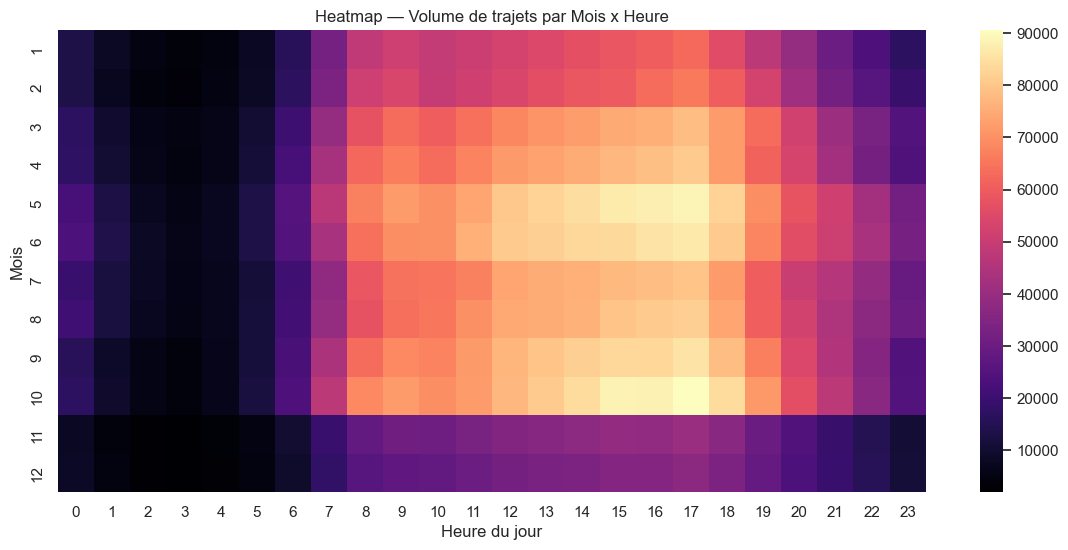

In [39]:
pivot_mois_heure = df.pivot_table(
    index="start_month",
    columns="start_hour",
    values="Trip ID",
    aggfunc="count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_mois_heure, cmap="magma")
plt.title("Heatmap — Volume de trajets par Mois x Heure")
plt.xlabel("Heure du jour")
plt.ylabel("Mois")
plt.show()

même conclusion que ci-dessus avec un apperçu mensuelle

**Durée par période :**

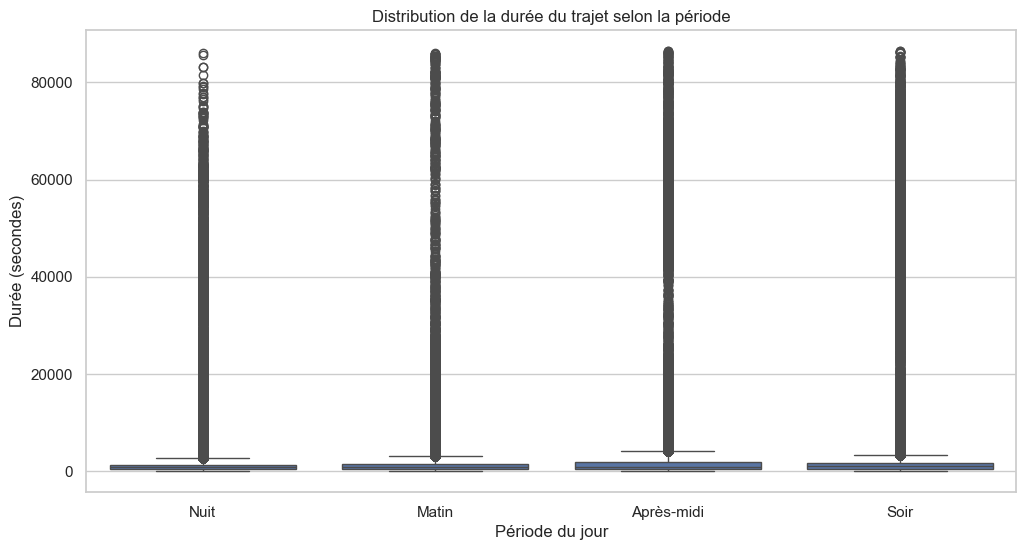

In [40]:
plt.figure()
sns.boxplot(x="period_of_day", y="Trip Seconds", data=df)
plt.title("Distribution de la durée du trajet selon la période")
plt.xlabel("Période du jour")
plt.ylabel("Durée (secondes)")
plt.show()

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\3631469536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


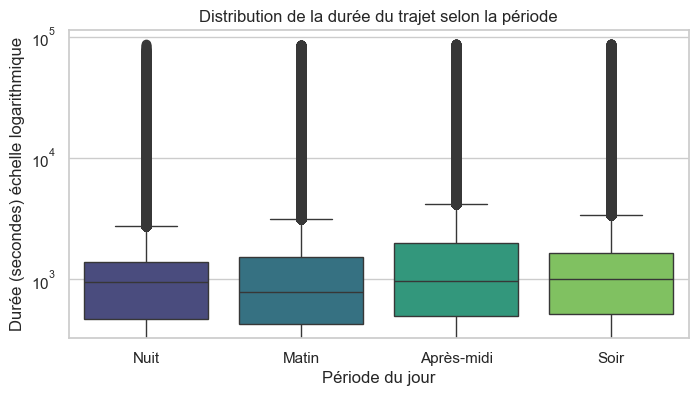

In [41]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x="period_of_day",
    y="Trip Seconds",
    data=df,
    palette="viridis"   
)

plt.title("Distribution de la durée du trajet selon la période")
plt.xlabel("Période du jour")
plt.ylabel("Durée (secondes) échelle logarithmique")
plt.yscale("log")

plt.show()

- La distribution des durées est très asymétrique, avec de nombreux trajets anormalement longs qui tirent les boxplots vers le haut.
- Les différences entre périodes (nuit, matin, après-midi, soir) sont faibles une fois les valeurs extrêmes prises en compte.
- Ce résultat suggère qu’une variable “période de la journée” n’apporte pas d’information significative pour modéliser la durée ou le prix, et que l’encodage cyclique (sin/cos) de l’heure est plus approprié.


**Distance moyenne par heure :**

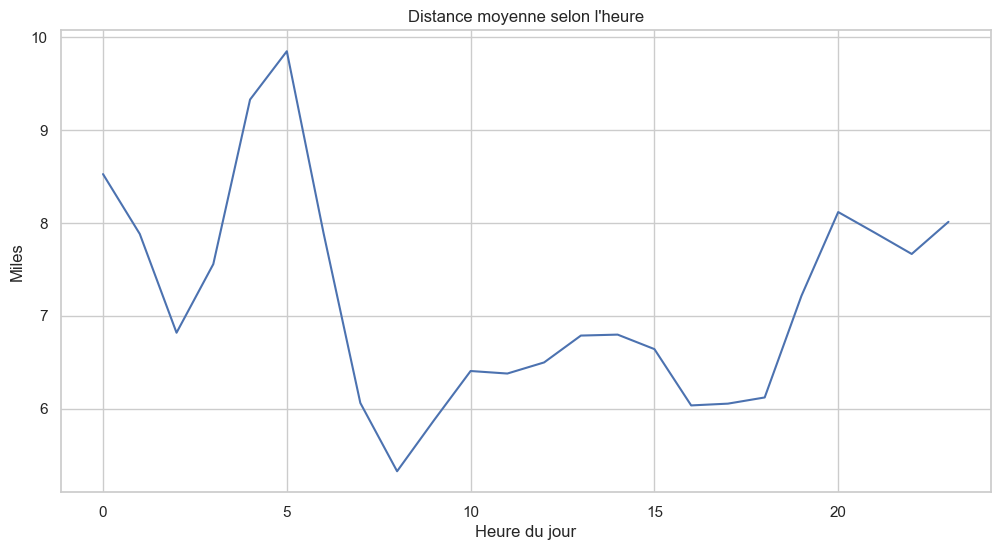

In [42]:
dist_heure = df.groupby("start_hour")["Trip Miles"].mean()

plt.figure()
dist_heure.plot()
plt.title("Distance moyenne selon l'heure")
plt.xlabel("Heure du jour")
plt.ylabel("Miles")
plt.show()

- La distance moyenne varie selon l’heure, avec des trajets plus longs entre 4h et 6h du matin, probablement liés à des déplacements vers l’aéroport ou des zones éloignées.
- En journée, la distance moyenne diminue puis reste relativement stable entre 6 et 18h, ce qui correspond à des trajets plus courts typiques des déplacements urbains.
- En soirée, la distance remonte légèrement, ce qui suggère des trajets plus longs liés aux sorties ou aux déplacements hors centre-ville.
- Ces variations horaires indiquent que l’heure contient de l’information pertinente pour la distance et donc pour le prix, ce qui justifie l’encodage cyclique (sin/cos) et la variable binaire nuit/jour.

### <span style="color:#1e90ff;">Analyse univariée des variables numériques</span>

**Statistiques Descriptives**

In [43]:
num_vars = [
    "Trip Seconds",
    "Trip Miles",
    "Fare",
    "Tips",
    "Tolls",
    "Extras",
    "Trip Total"
]

df[num_vars].describe()

,Trip Seconds,Trip Miles,Fare,Tips,Tolls,Extras,Trip Total
count,12204111.000,12204111.000,12204111.000,12204111.000,12204111.000,12204111.000,12204111.000
mean,1250.068,6.696,22.768,2.839,0.031,2.087,27.957
std,1629.722,7.647,31.977,4.271,4.105,9.169,36.585
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,480.000,1.070,8.500,0.000,0.000,0.000,10.250
50%,926.000,3.220,15.650,0.000,0.000,0.000,18.600
75%,1695.000,11.800,34.250,4.000,0.000,2.000,42.310
max,86400.000,3397.800,9999.750,400.000,5550.000,5559.500,9999.750


In [44]:
cond_sec = df["Trip Seconds"] < 30
cond_miles = df["Trip Miles"] < 0.1 
cond_fare = df["Fare"] < 3


n_sec = cond_sec.sum()
n_miles = cond_miles.sum()
n_fare = cond_fare.sum()

print(f"Durée < 30 sec : {n_sec}")
print(f"Distance < 0.1 mile : {n_miles}")
print(f"Fare < 3$ : {n_fare}")

Durée < 30 sec : 627619
Distance < 0.1 mile : 1227724
Fare < 3$ : 102129


In [45]:
# Nettoyage minimal cohérent avec les données taxi

# 1. Durée minimale réaliste : >= 30 sec
df = df[df["Trip Seconds"] >= 30]

# 2. Distance minimale réaliste : >= 0.1 mile environ 163 m
df = df[df["Trip Miles"] >= 0.1]

# 3. Prix minimal réaliste (tarif d'ouverture Chicago) : >= 3$
df = df[df["Fare"] >= 3]

# 4. Distance maximale réaliste : <= 50 miles (au-delà = erreurs GPS) env 80km
df = df[df["Trip Miles"] <= 50]

# 5. Nettoyage distance = 0 & durée > 120 sec déjà fait, mais au cas où :
df = df[~((df["Trip Miles"] == 0) & (df["Trip Seconds"] > 120))]

- Nous appliquons une série de seuils réalistes afin de garantir la cohérence des trajets conservés pour la modélisation.
- Une durée minimale de 30 secondes est imposée, car un trajet réel ne peut pas être instantané.
- Une distance minimale de 0.1 mile (~160 m) est retenue pour éviter les erreurs GPS ou les enregistrements partiels.
- Le tarif Fare doit être au moins égal à 3 dollars, correspondant au tarif d’ouverture du compteur à Chicago.
- Les distances supérieures à 50 miles sont supprimées : ces valeurs sont dues à des erreurs de géolocalisation, car un trajet taxi urbain ne dépasse jamais cette distance.
- Après nettoyage, le dataset conserve uniquement des observations plausibles tout en maintenant un volume important pour la modélisation.


In [46]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df[num_vars].describe()

,Trip Seconds,Trip Miles,Fare,Tips,Tolls,Extras,Trip Total
count,10942196.000,10942196.000,10942196.000,10942196.000,10942196.000,10942196.000,10942196.000
mean,1329.859,7.411,22.743,2.875,0.031,2.024,27.915
std,1524.221,6.960,17.226,4.187,3.442,8.087,24.210
min,30.000,0.100,3.000,0.000,0.000,0.000,3.000
25%,551.000,1.460,8.750,0.000,0.000,0.000,10.750
50%,1020.000,4.440,16.630,0.500,0.000,0.000,19.250
75%,1775.000,12.550,34.500,4.000,0.000,3.000,42.750
max,86396.000,50.000,6950.690,400.000,4444.440,5559.500,8940.880


- Nous identifions deux types d’anomalies  :
  - des trajets ayant une durée égale à 0 seconde, ce qui est impossible en pratique 
  - des trajets ayant une distance nulle mais une durée supérieure à 2 minutes, généralement causés par des erreurs de mesure GPS ou des enregistrements incorrects du compteur.


- Nous appliquons ensuite des seuils minimaux réalistes pour garantir la cohérence économique des trajets.
- Un trajet réel dure rarement moins de 30 secondes, parcourt au moins 0.1 mile (≈160 m) et implique un tarif d’ouverture d’au moins 3 dollars.
- Ces règles permettent de retirer les enregistrements aberrants ou issus d’erreurs de compteur, tout en conservant des données plausibles pour la modélisation.


**Percentiles :**

In [47]:
percentiles = [0.01, 0.05, 0.95, 0.99]

outlier_table = df[num_vars].quantile(percentiles).T
outlier_table.columns = [f"{int(p*100)}%" for p in percentiles]
display(outlier_table)

,1%,5%,95%,99%
Trip Seconds,133.000,256.000,3300.000,4620.000
Trip Miles,0.280,0.600,18.550,27.150
Fare,4.250,5.500,50.370,71.500
Tips,0.000,0.000,11.000,15.750
Tolls,0.000,0.000,0.000,0.000
Extras,0.000,0.000,6.000,30.000
Trip Total,4.500,6.250,66.600,97.000


- L’analyse des percentiles montre que les valeurs extrêmes (1%–99%) sont cohérentes avec des trajets taxi réels.
- Les durées supérieures à 1h, les distances supérieures à 25 miles ou les prix supérieurs à 70 dollars correspondent à des courses longues mais plausibles.
- L’objectif ici est surtout d’identifier des anomalies éventuelles ; aucune coupure automatique n’est nécessaire.
- Les seuils minimaux retenus (durée ≥ 30 sec, distance ≥ 0.1 mile, fare ≥ 3 dollars) restent cohérents avec la distribution observée.


**Histogrammes :**

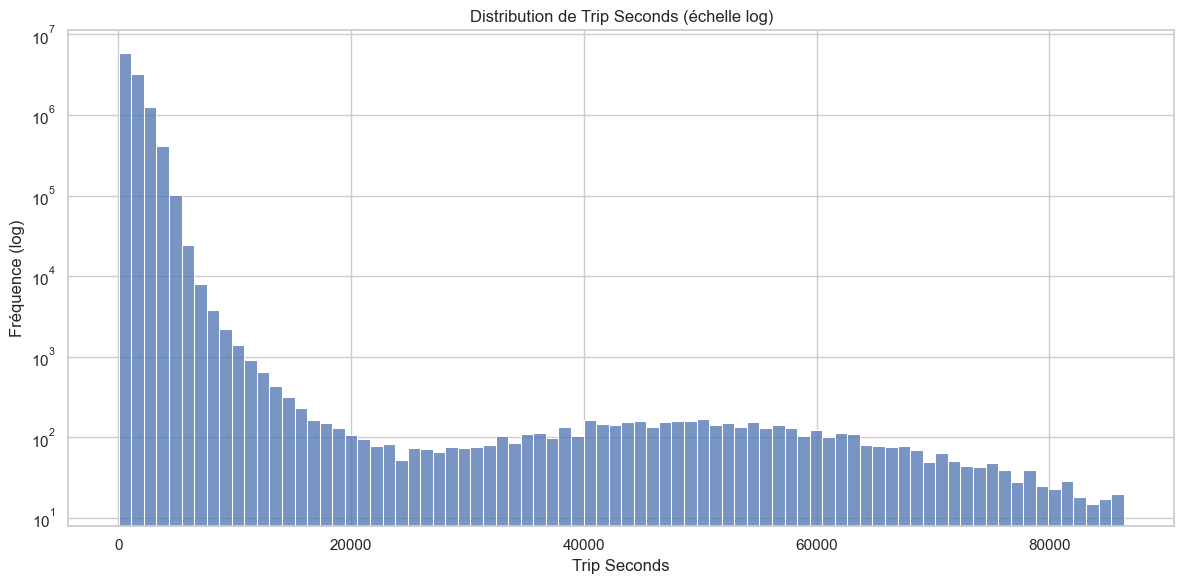

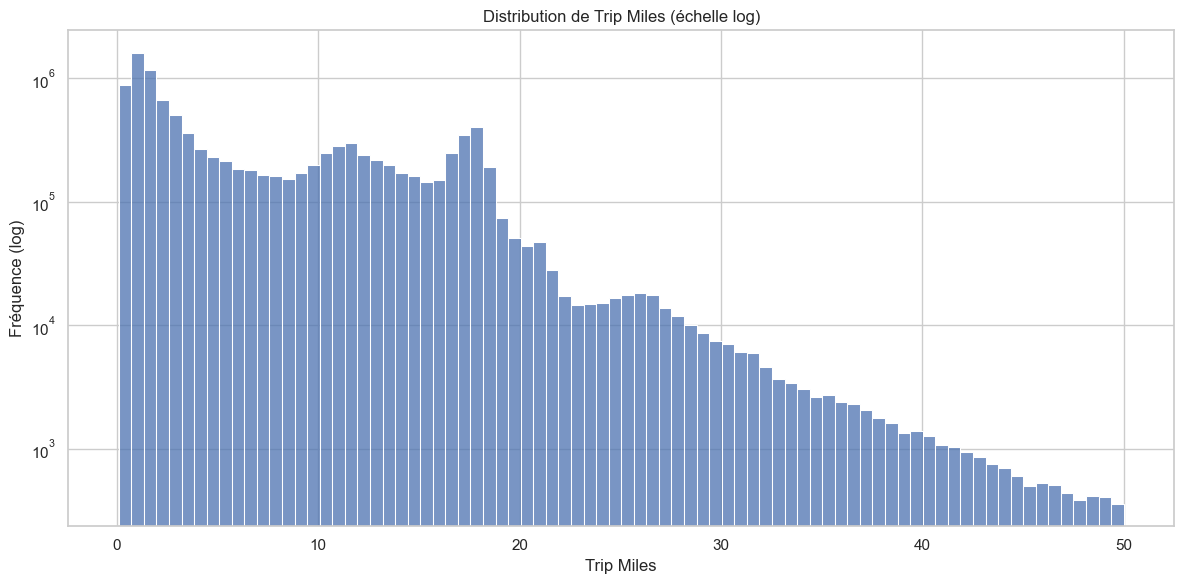

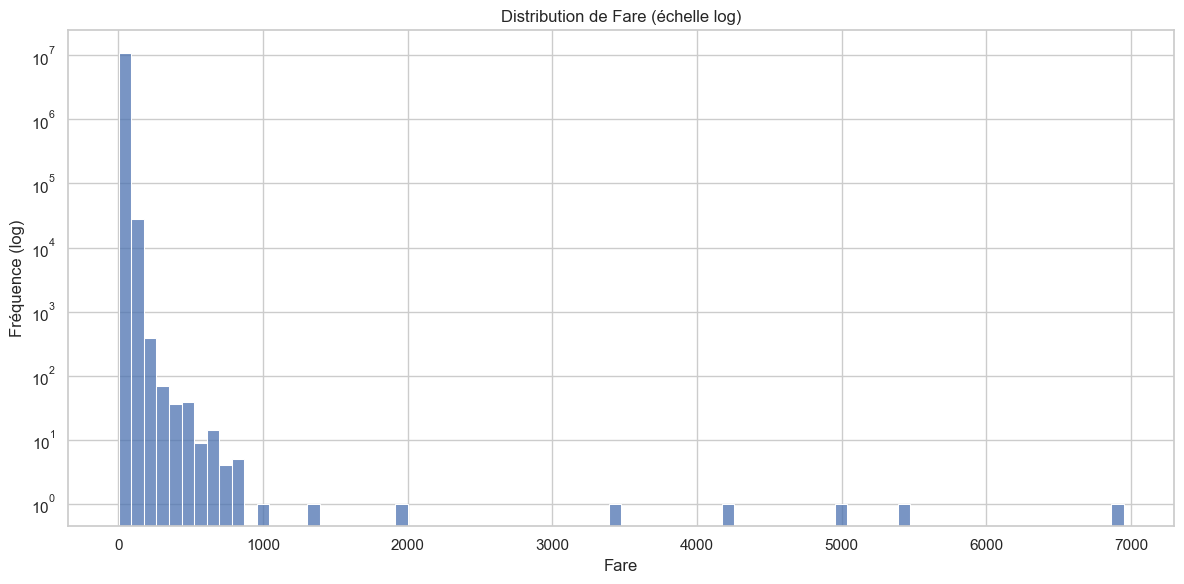

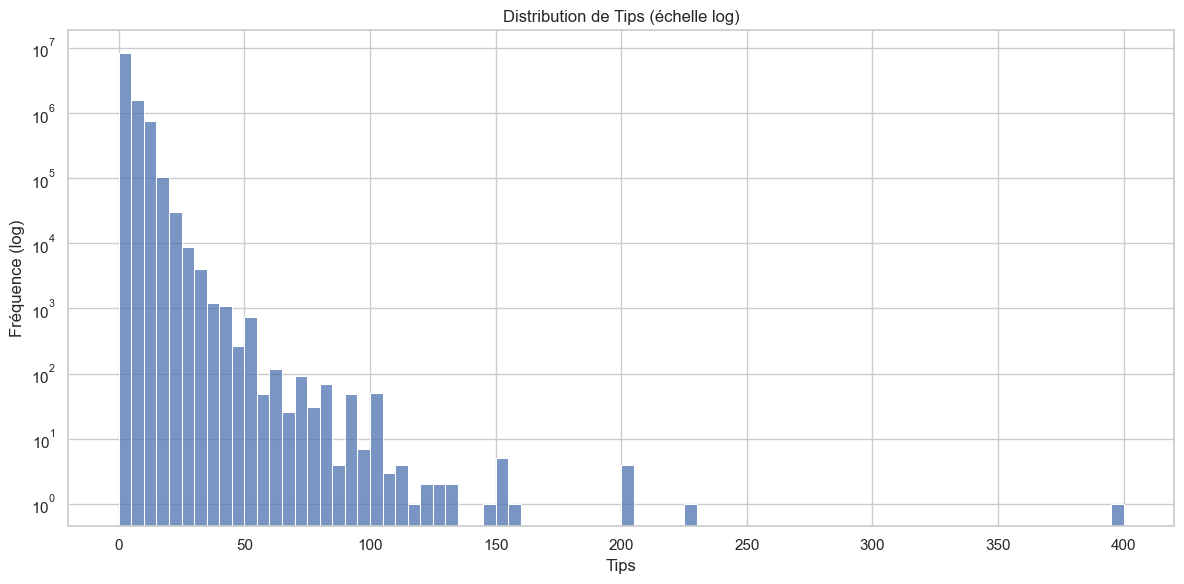

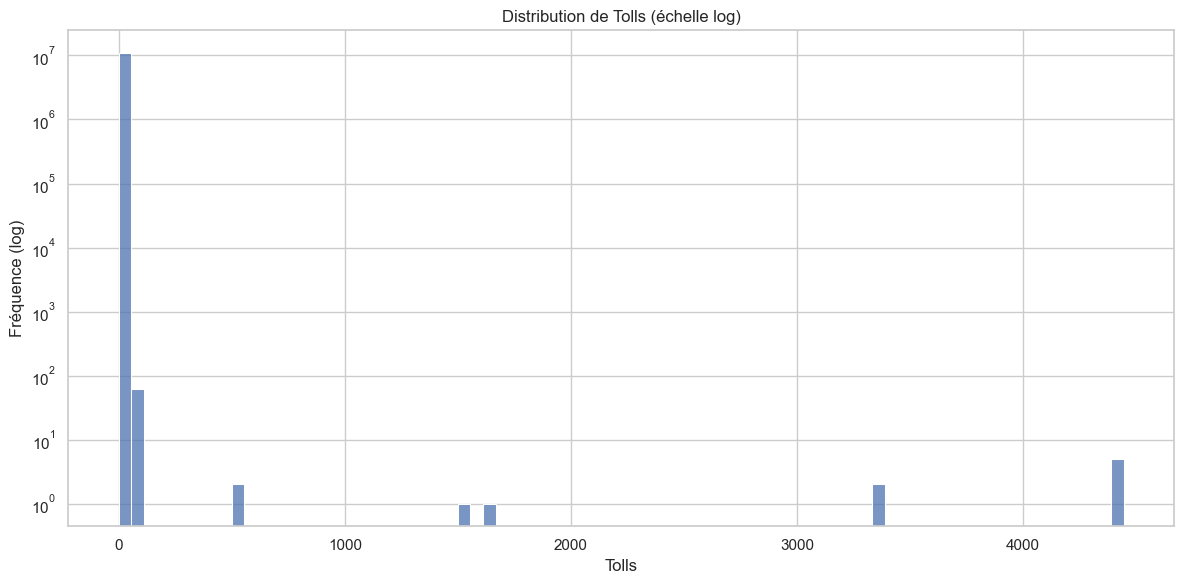

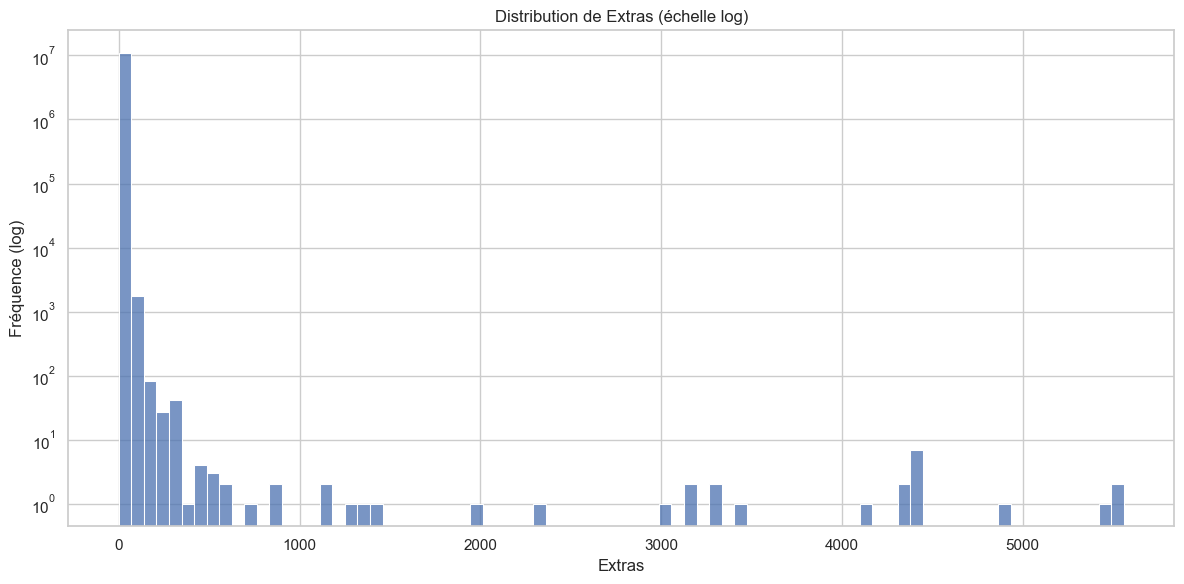

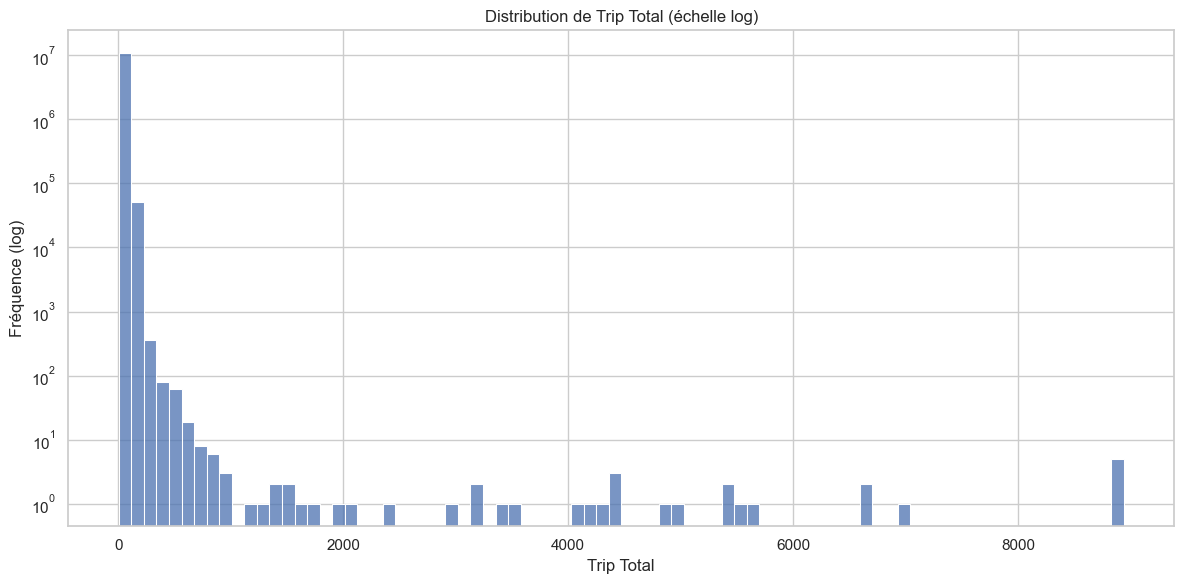

In [48]:
for col in num_vars:
    plt.figure()
    sns.histplot(df[col], bins=80, kde=False)
    plt.yscale("log")          # échelle logarithmique
    plt.title(f"Distribution de {col} (échelle log)")
    plt.xlabel(col)
    plt.ylabel("Fréquence (log)")
    plt.tight_layout()
    plt.show()

In [49]:
# distances
df = df[df["Trip Miles"] <= 50]

# fare et total
df = df[df["Fare"] <= 200]
df = df[df["Trip Total"] <= 300]

# tips / extras / tolls
df = df[df["Tips"] <= 100]
df = df[df["Extras"] <= 50]
df = df[df["Tolls"] <= 100]

- Les distributions en échelle logarithmique révèlent la présence d’outliers extrêmes (valeurs allant jusqu’à plusieurs milliers de dollars).
- Ces valeurs sont impossibles dans le contexte des taxis de Chicago et proviennent d’erreurs de compteur, de GPS ou d’enregistrements corrompus.
- Pour garantir la stabilité du modèle et conserver uniquement des données réalistes, nous appliquons des seuils maximaux : 
  - Fare ≤ 200 $ 
  - Trip Total ≤ 300 $ 
  - Tips ≤ 100 $ 
  - Extras ≤ 50 $ 
  - Tolls ≤ 100 $ 
  - Trip Miles ≤ 50 miles.
- Après ce nettoyage, les distributions deviennent cohérentes avec l’activité réelle des taxis et exploitables pour la modélisation.


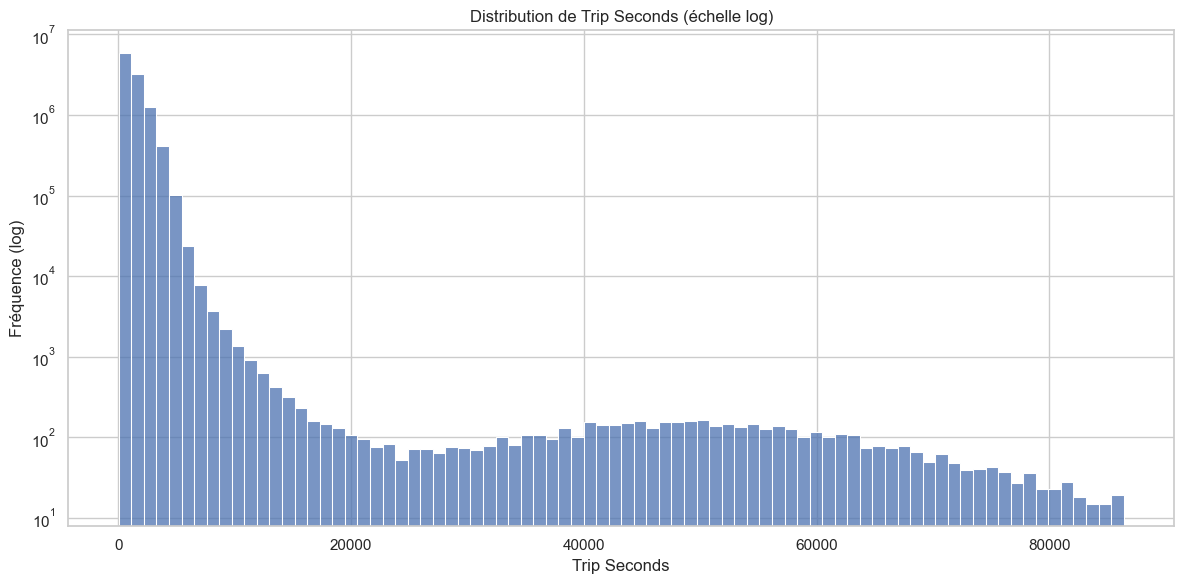

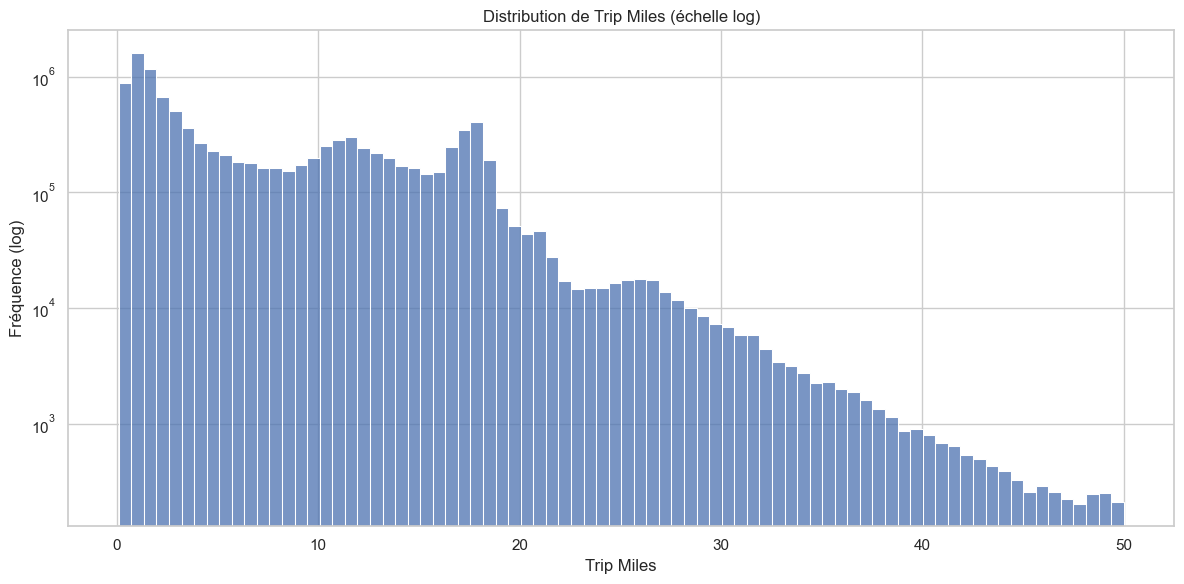

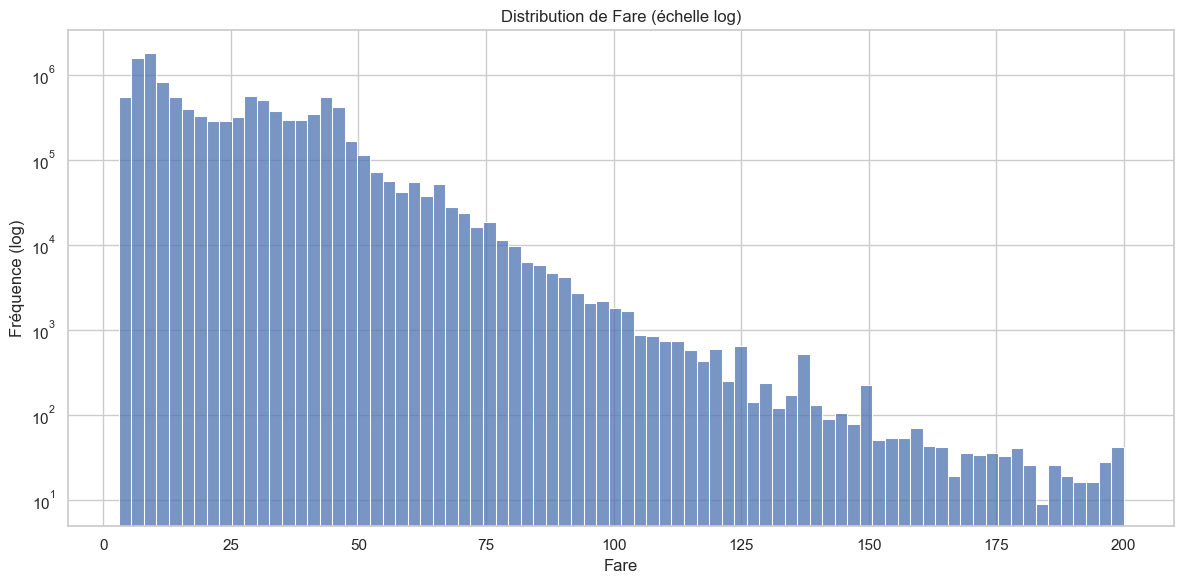

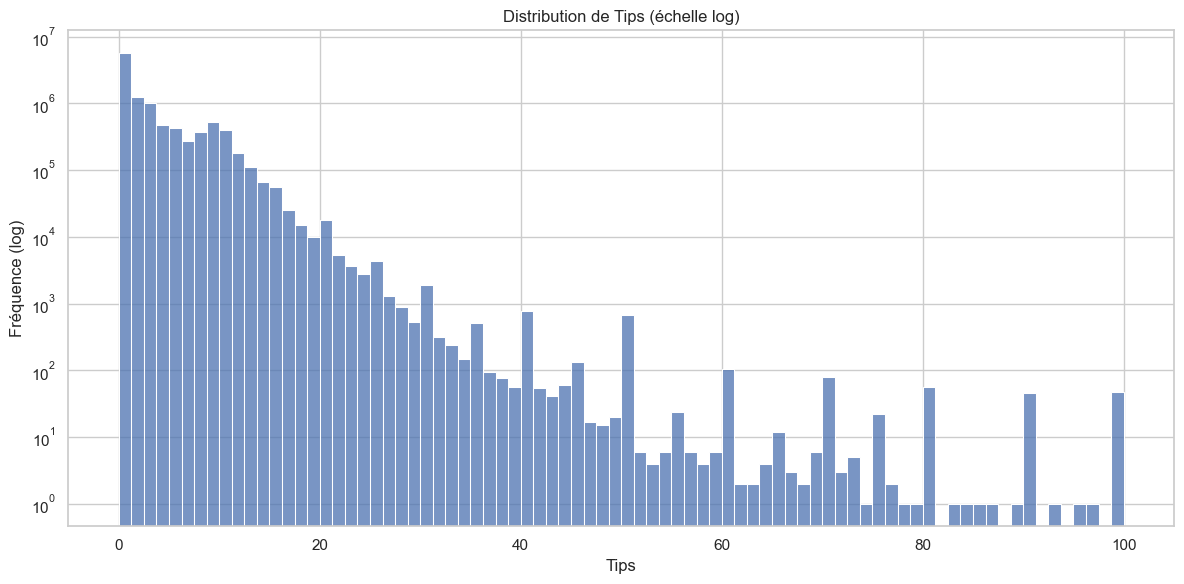

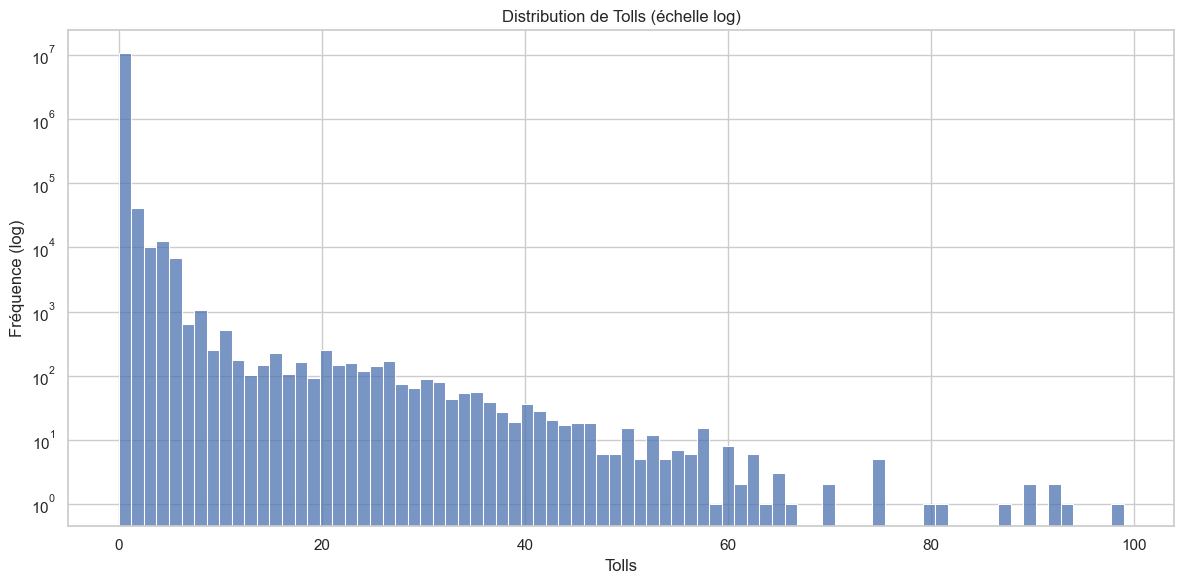

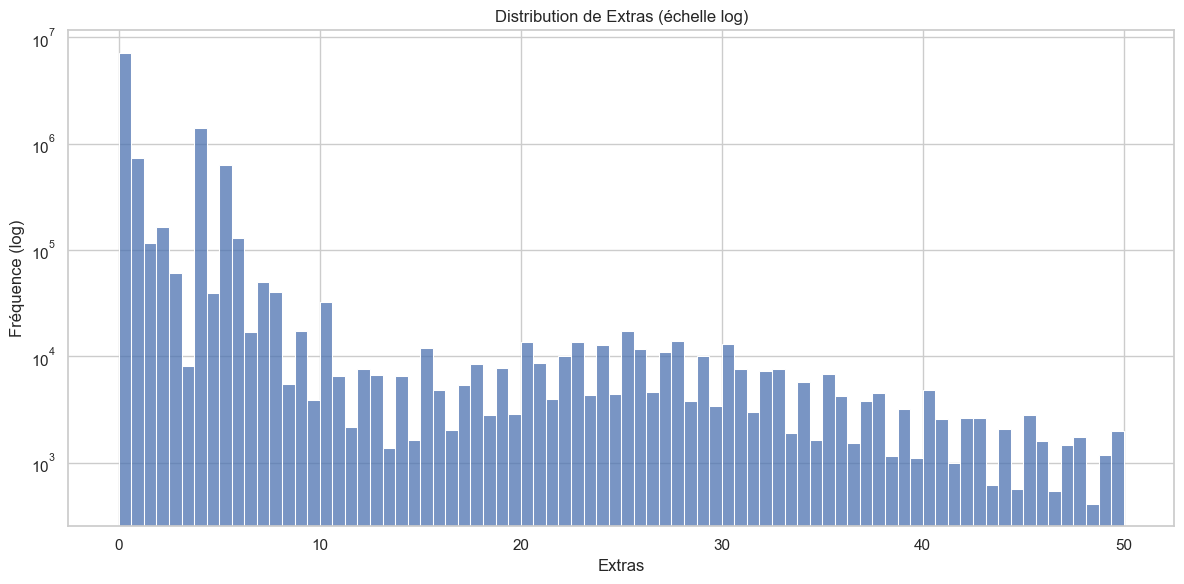

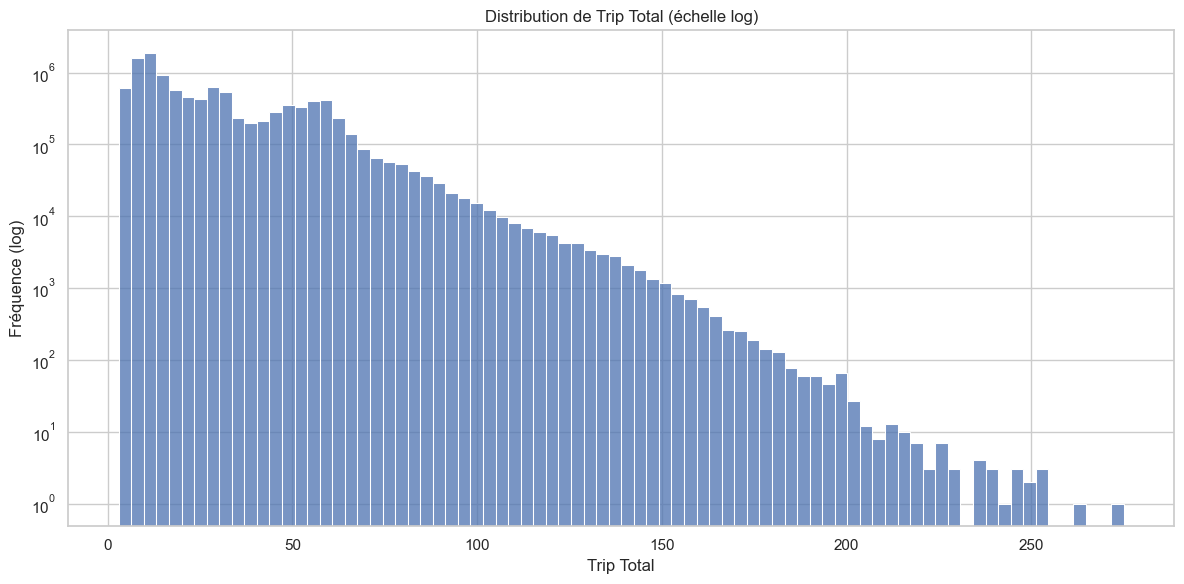

In [50]:
for col in num_vars:
    plt.figure()
    sns.histplot(df[col], bins=80, kde=False)
    plt.yscale("log")          
    plt.title(f"Distribution de {col} (échelle log)")
    plt.xlabel(col)
    plt.ylabel("Fréquence (log)")
    plt.tight_layout()
    plt.show()

# <span style="color:#1e90ff;">Analyse univariée des variables catégorielles</span>

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10927821 entries, 0 to 12204110
Data columns (total 25 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Unnamed: 0              int64         
 1   Trip ID                 object        
 2   Taxi ID                 object        
 3   Trip Start Timestamp    datetime64[ns]
 4   Trip End Timestamp      datetime64[ns]
 5   Trip Seconds            float64       
 6   Trip Miles              float64       
 7   Pickup Community Area   float64       
 8   Dropoff Community Area  float64       
 9   Fare                    float64       
 10  Tips                    float64       
 11  Tolls                   float64       
 12  Extras                  float64       
 13  Trip Total              float64       
 14  Payment Type            object        
 15  Company                 object        
 16  start_hour              int32         
 17  start_weekday           int32         
 18  start

**Fréquences de Payment Type :**

In [52]:
payment_counts = df["Payment Type"].value_counts()
print("=== Payment Type — fréquences ===")
print(payment_counts)

=== Payment Type — fréquences ===
Payment Type
Credit Card    4173035
Cash           2556340
Mobile         2324719
Prcard         1415987
Unknown         434141
No Charge        19411
Dispute           4188
Name: count, dtype: int64


In [53]:
# 1. Suppression des types incohérents
df = df[~df["Payment Type"].isin(["No Charge", "Dispute"])]

# 2. Frequency encoding
freq = df["Payment Type"].value_counts(normalize=True)
df["payment_freq"] = df["Payment Type"].map(freq)


- La variable Payment Type présente plusieurs catégories : carte, cash, mobile, prcard, ainsi que quelques classes mineures telles que "No Charge" et "Dispute".
- Les catégories "No Charge" et "Dispute" ne correspondent pas à un paiement réel et sont supprimées du dataset afin d'éviter de fausser la modélisation du prix.
- Pour les catégories restantes, un frequency encoding est appliqué : chaque type de paiement est remplacé par sa fréquence d'apparition dans le dataset.
- Ce choix permet de représenter efficacement cette variable sans explosion de dimensions et sans imposer d'ordre arbitraire, ce qui est idéal pour les modèles d’arbres (XGBoost, RandomForest, CatBoost).


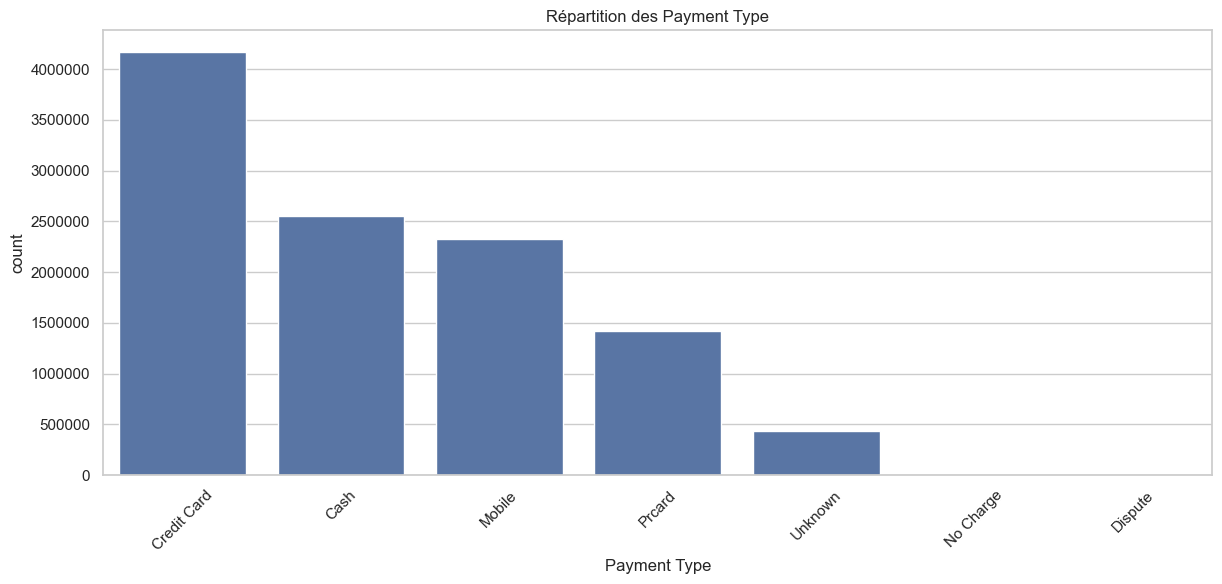

In [54]:
plt.figure()
sns.countplot(data=df, x="Payment Type", order=payment_counts.index)
plt.title("Répartition des Payment Type")
plt.xticks(rotation=45)
plt.tight_layout()

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
plt.show()

**Carte vs Cash dans le temps (mensuel)**

<Figure size 1200x600 with 0 Axes>

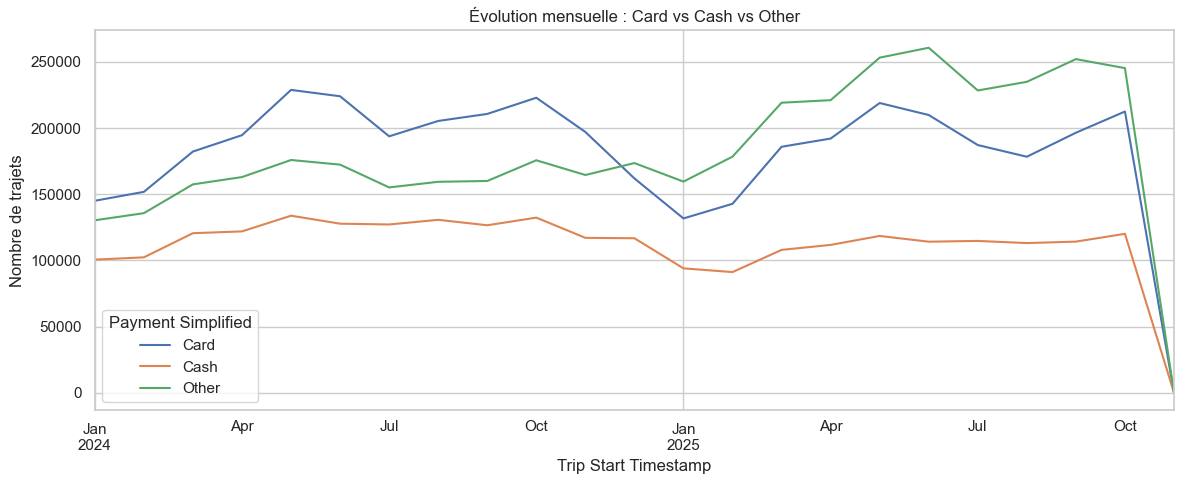

In [55]:
df["Payment Simplified"] = df["Payment Type"].replace({
    "Credit Card": "Card",
    "Cash": "Cash"
}).where(df["Payment Type"].isin(["Credit Card", "Cash"]), "Other")

monthly_pay = df.groupby([
    df["Trip Start Timestamp"].dt.to_period("M"),
    "Payment Simplified"
]).size().unstack().fillna(0)

monthly_pay.index = monthly_pay.index.to_timestamp()

plt.figure()
monthly_pay.plot(figsize=(12, 5))
plt.title("Évolution mensuelle : Card vs Cash vs Other")
plt.ylabel("Nombre de trajets")
plt.tight_layout()
plt.show()

- Les paiements par carte (« Card ») sont largement dominants tout au long de la période.  
  Ils représentent en moyenne entre 180 000 et 230 000 trajets par mois.

- Les paiements « Other » (principalement Mobile, Prcard, etc.) sont le second mode le plus utilisé,
  avec un volume légèrement inférieur à celui des paiements par carte, mais globalement stable.

- Les paiements en espèces (« Cash ») sont nettement moins fréquents, autour de 100 000 à 130 000 trajets par mois.
  Leur utilisation reste plutôt stable dans le temps, avec une légère baisse en hiver.

- On observe globalement une saisonnalité : hausse au printemps/été, baisse en fin d'année.
  Cela semble refléter une saisonnalité générale des trajets plutôt qu’un changement de préférence de paiement.

- Le dernier point proche de 0 correspond à une coupure du dataset (mois incomplet), et ne doit pas être interprété.


PRCARD = Prepaid Card (carte prépayée)

Cela correspond à :

des cartes prépayées utilisées pour les taxis (par des entreprises, hôtels, organismes…)

des programmes type “Taxi Voucher”, souvent fournis aux personnes âgées, aux hôpitaux, ou aux programmes municipaux

des cartes préchargées par les compagnies de transport

parfois des “transport benefits cards” (avantages employeurs)

Oberservation : 

La variable “Payment freq ne doit pas être utilisée pour prédire le montant de la course, car elle est décidée après le trajet. Le mode de paiement dépend du prix (les trajets chers sont plus souvent payés en carte), donc l’utiliser dans un modèle reviendrait à donner au modèle une information qu’il ne devrait pas connaître avant la prédiction. C’est un cas typique de data leakage : la variable est informative, mais illégitime. Elle doit donc être exclue des features du modèle.

**Company :**

=== Top 20 compagnies ===


Company
Flash Cab                            2331730
Taxi Affiliation Services            1331250
Taxicab Insurance Agency Llc         1306867
Sun Taxi                             1249996
City Service                         1121557
Chicago Independents                  691874
5 Star Taxi                           545117
Blue Ribbon Taxi Association          490377
Globe Taxi                            394345
Medallion Leasin                      287681
Transit Administrative Center Inc     279703
Tac - Yellow Cab Association          181941
Choice Taxi Association Inc           142636
Taxicab Insurance Agency, LLC         104860
Chicago City Taxi Association          95705
Choice Taxi Association                90484
Wolley Taxi                            37875
Top Cab                                33426
Koam Taxi Association                  28282
U Taxicab                              25883
Name: count, dtype: int64

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\2153590207.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


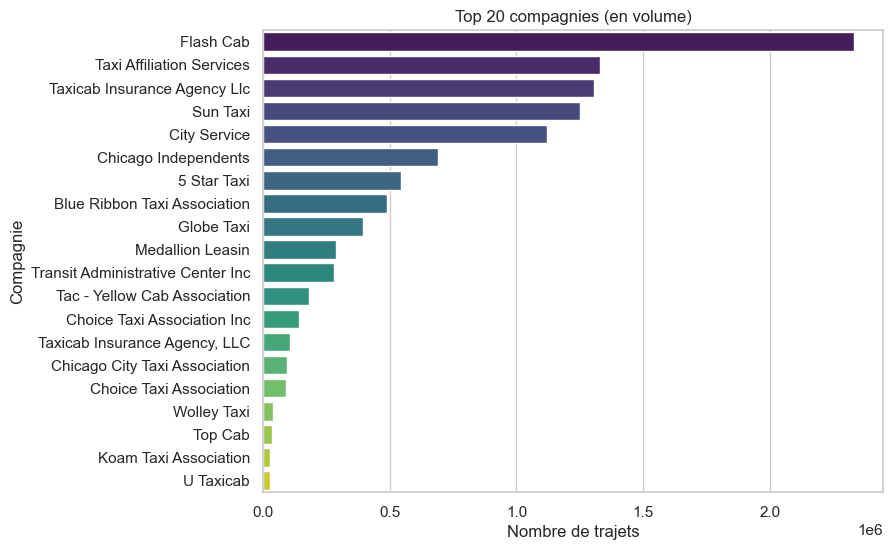

In [56]:
company_counts = df["Company"].value_counts()

print("=== Top 20 compagnies ===")
display(company_counts.head(20))

plt.figure(figsize=(8,6))

sns.barplot(
    x=company_counts.head(20).values,
    y=company_counts.head(20).index,
    palette="viridis"   
)

plt.title("Top 20 compagnies (en volume)")
plt.xlabel("Nombre de trajets")
plt.ylabel("Compagnie")
plt.show()

In [57]:
company_freq = df["Company"].value_counts(normalize=True)


threshold = 0.001
small_companies = company_freq[company_freq < threshold].index

print(f"Nombre de petites compagnies regroupées : {len(small_companies)}")


df["Company_clean"] = df["Company"].replace(small_companies, "Other")


company_clean_freq = df["Company_clean"].value_counts(normalize=True)

print("=== Top 10 Company_clean ===")
print(company_clean_freq.head(10))


df["company_freq"] = df["Company_clean"].map(company_clean_freq)

df[["Company_clean", "company_freq"]].head()

Nombre de petites compagnies regroupées : 21
=== Top 10 Company_clean ===
Company_clean
Flash Cab                      0.214
Taxi Affiliation Services      0.122
Taxicab Insurance Agency Llc   0.120
Sun Taxi                       0.115
City Service                   0.103
Chicago Independents           0.063
5 Star Taxi                    0.050
Blue Ribbon Taxi Association   0.045
Globe Taxi                     0.036
Medallion Leasin               0.026
Name: proportion, dtype: float64


,Company_clean,company_freq
0,Flash Cab,0.214
1,Flash Cab,0.214
2,Globe Taxi,0.036
3,City Service,0.103
4,Blue Ribbon Taxi Association,0.045


- La variable Company contient un grand nombre de compagnies avec des fréquences très faibles.
- Pour réduire le bruit et éviter l'explosion dimensionnelle, toutes les compagnies représentant moins de 0.1 % des trajets sont regroupées dans une catégorie « Other ».
- Ensuite, un frequency encoding est appliqué sur la variable regroupée.
- Le frequency encoding capture l’importance relative des compagnies tout en restant compact et efficace pour des modèles d’arbres comme RandomForest ou XGBoost.

| Niveau du HHI         | Concentration du marché | Interprétation                          |
| --------------------- | ----------------------- | --------------------------------------- |
| **HHI < 0.15**        | Faible                  | Marché très concurrentiel               |
| **0.15 ≤ HHI < 0.25** | Modérée                 | Quelques acteurs plus gros              |
| **HHI ≥ 0.25**        | Forte                   | Marché dominé, risque de quasi-monopole |
| **HHI ≥ 0.50**        | Très forte              | 2–3 acteurs contrôlent presque tout     |


In [58]:
company_share = company_counts / company_counts.sum()
hhi = (company_share**2).sum()
print(f"HHI (Herfindahl-Hirschman Index) : {hhi:.4f}")


top5_share = company_share.head(5).sum()
print(f"Top 5 compagnies — part de marché : {top5_share*100:.2f}%")

HHI (Herfindahl-Hirschman Index) : 0.1107
Top 5 compagnies — part de marché : 67.33%


In [59]:
df.shape

(10904222, 29)

In [60]:
pickup_counts = df["Pickup Community Area"].value_counts()
dropoff_counts = df["Dropoff Community Area"].value_counts()

print("=== Top 10 Pickup Areas ===")
display(pickup_counts.head(10))

print("=== Top 10 Dropoff Areas ===")
display(dropoff_counts.head(10))

print("=== Bottom 10 Pickup Areas ===")
display(pickup_counts.tail(10))

print("=== Bottom 10 Dropoff Areas ===")
display(dropoff_counts.tail(10))

=== Top 10 Pickup Areas ===


Pickup Community Area
8.000     2375396
76.000    2338505
32.000    1772274
28.000    1060133
33.000     384193
6.000      357116
56.000     333896
7.000      228781
-1.000     203511
3.000      176272
Name: count, dtype: int64

=== Top 10 Dropoff Areas ===


Dropoff Community Area
8.000     2590754
32.000    1819591
28.000    1056400
-1.000     951113
6.000      480317
76.000     464396
7.000      434184
33.000     428497
24.000     259604
3.000      201352
Name: count, dtype: int64

=== Bottom 10 Pickup Areas ===


Pickup Community Area
65.000    3857
17.000    3843
9.000     3377
62.000    3371
74.000    3178
57.000    2780
64.000    2630
63.000    1702
20.000    1294
18.000    1286
Name: count, dtype: int64

=== Bottom 10 Dropoff Areas ===


Dropoff Community Area
64.000    4786
47.000    4537
52.000    4164
20.000    4044
62.000    3881
57.000    3831
55.000    3370
63.000    3055
18.000    2684
74.000    1799
Name: count, dtype: int64

- Les zones 8, 76, 32 et 28 concentrent la majorité des départs et arrivées. 
  Elles correspondent aux zones les plus actives de Chicago : Downtown, Near North Side, O’Hare Airport et les quartiers centraux.

- La zone 8 est particulièrement dominante : plus de 2.3M pickups et 2.5M dropoffs. 
  Cela reflète clairement la très forte activité dans le centre-ville.

- La zone 76 (probablement O'Hare Airport) représente également une part massive du trafic, avec plus de 2.3M pickups et près de 500k dropoffs.

- La zone 32 (Near North Side) et la zone 28 (Loop) complètent les principales zones d’activité, cohérentes avec les zones touristiques et professionnelles.

- À l’inverse, certaines zones sont très peu utilisées : les zones 18, 20, 63, 64, 74, etc. ont moins de 4 000 pickups / dropoffs chacune. 
  Il s’agit souvent de quartiers résidentiels éloignés ou moins denses.

- La zone -1 apparaît dans les deux distributions (≈ 200k pickups, ≈ 950k dropoffs). 
  Ce code correspond aux trajets dont la zone n’a pas pu être déterminée (erreur GPS ou données manquantes). 
  Cette catégorie doit être conservée mais traitée comme une zone "Unknown".


In [61]:
df.shape

(10904222, 29)

In [62]:
# Frequency encoding Pickup
pickup_freq = df["Pickup Community Area"].value_counts(normalize=True)
df["pickup_freq"] = df["Pickup Community Area"].map(pickup_freq)

# Frequency encoding Dropoff
dropoff_freq = df["Dropoff Community Area"].value_counts(normalize=True)
df["dropoff_freq"] = df["Dropoff Community Area"].map(dropoff_freq)

**Visualisation top 10**

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\3631034977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


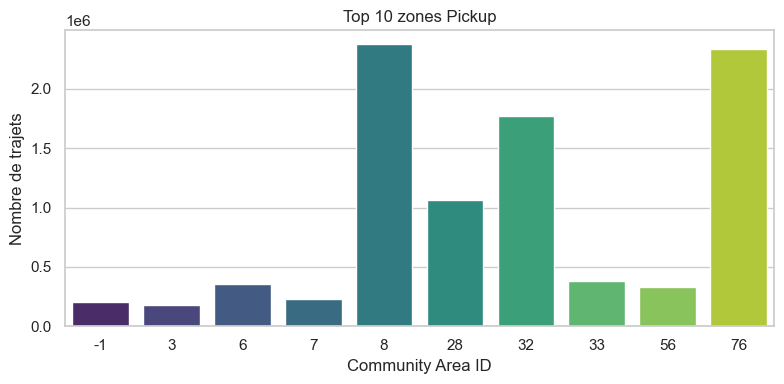

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\3631034977.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


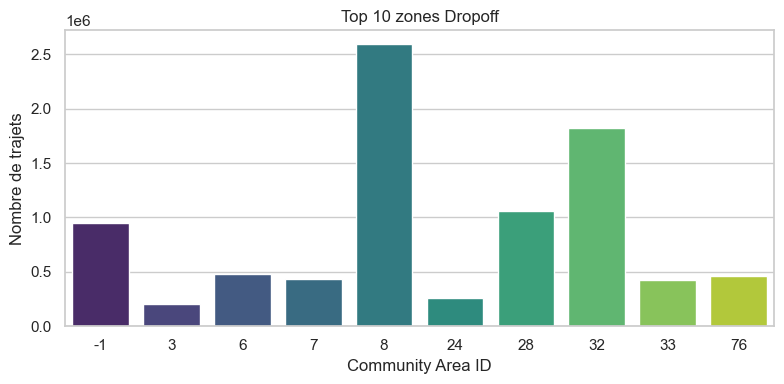

Nombre de Pickup = -1 : 203511
Nombre de Dropoff = -1 : 951113


In [63]:
plt.figure(figsize=(8,4))
sns.barplot(
    x=pickup_counts.head(10).index.astype(int),
    y=pickup_counts.head(10).values,
    palette="viridis"
)
plt.title("Top 10 zones Pickup")
plt.xlabel("Community Area ID")
plt.ylabel("Nombre de trajets")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(
    x=dropoff_counts.head(10).index.astype(int),
    y=dropoff_counts.head(10).values,
    palette="viridis"
)
plt.title("Top 10 zones Dropoff")
plt.xlabel("Community Area ID")
plt.ylabel("Nombre de trajets")
plt.tight_layout()
plt.show()

# Analyse du code -1 (Unknown)
unk_pickup = (df["Pickup Community Area"] == -1).sum()
unk_dropoff = (df["Dropoff Community Area"] == -1).sum()

print(f"Nombre de Pickup = -1 : {unk_pickup}")
print(f"Nombre de Dropoff = -1 : {unk_dropoff}")

## <span style="color:#1e90ff;">Analyse Bivariée : Relation entre les variables</span>

##### Trip Miles vs Fare

In [64]:
for col in df.columns :
    print(col)

Unnamed: 0
Trip ID
Taxi ID
Trip Start Timestamp
Trip End Timestamp
Trip Seconds
Trip Miles
Pickup Community Area
Dropoff Community Area
Fare
Tips
Tolls
Extras
Trip Total
Payment Type
Company
start_hour
start_weekday
start_month
start_date
is_weekend
period_of_day
hour_sin
hour_cos
is_night
payment_freq
Payment Simplified
Company_clean
company_freq
pickup_freq
dropoff_freq


#### Trip Miles vs Fare : Prix hors pourboire,... vs Distance 

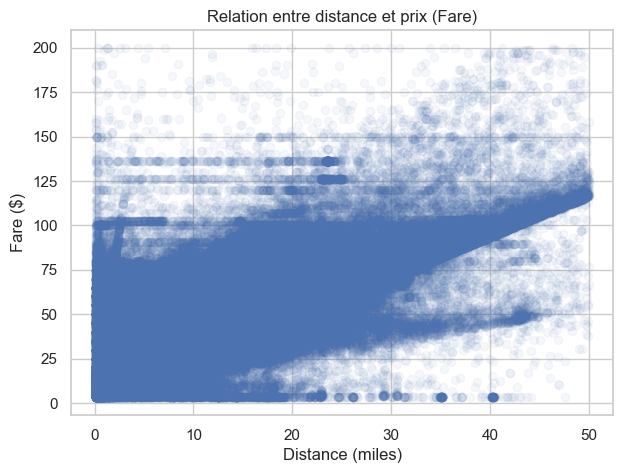

In [85]:
plt.figure(figsize=(7,5))
plt.scatter(df['Trip Miles'], df['Fare'], alpha=0.05)
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.title("Relation entre distance et prix (Fare)")
plt.show()

- Tendance globale positive : le prix (Fare) augmente avec la distance parcourue, avec une relation plutot linéaire. Cela prouve qu'en général le prix augmente avec la distance.

- Forte dispersion (hétéroscédasticité) : la variabilité du prix augmente avec la distance, indiquant que de longs trajets peuvent coûter très différemment selon les conditions.

### Trip Seconds vs Fare : Durée en seconde vs Prix 

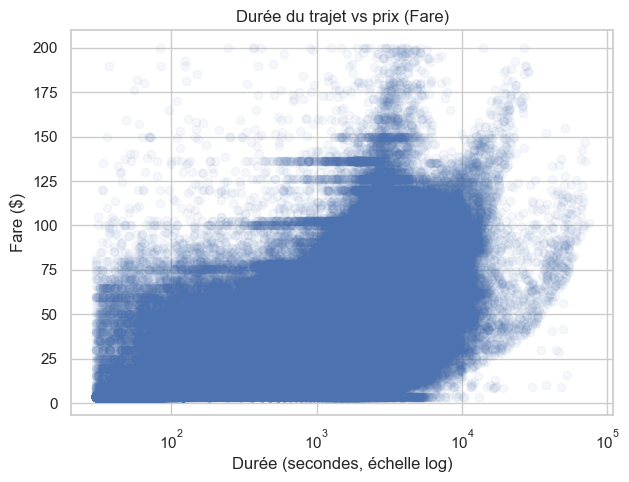

In [86]:
plt.figure(figsize=(7,5))
plt.scatter(df['Trip Seconds'], df['Fare'], alpha=0.05)
plt.xscale("log") # échelle logarithmique pour mieux visualiser
plt.xlabel("Durée (secondes, échelle log)")
plt.ylabel("Fare ($)")
plt.title("Durée du trajet vs prix (Fare)")
plt.show()


* La durée du trajet est globalement corrélée au prix, mais la relation est très dispersée.
* De nombreux facteurs (distance, zones, surcharges…) influencent fortement le prix pour une même durée.
* Le nuage montre des plateaux tarifaires et des outliers, indiquant une tarification non linéaire et complexe.


### Trip Miles vs Trip Seconds : Durée du trajet vs temps de trajet en seconde 

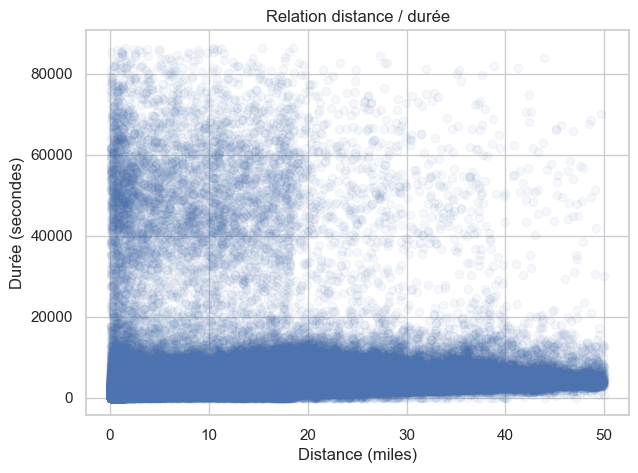

In [67]:
plt.figure(figsize=(7,5))
plt.scatter(df['Trip Miles'], df['Trip Seconds'], alpha=0.05)
plt.xlabel("Distance (miles)")
plt.ylabel("Durée (secondes)")
plt.title("Relation distance / durée")
plt.show()



- relation globalement positive, plus la distance augmente, plus la durée augmente. La relation est proche d’une droite mais pas parfaite : forte dispersion autour de la tendance.

- Variabilité de vitesse : la dispersion verticale indique des vitesses très variables (trafic, arrêts, attente). Même pour distances similaires on observe durées très différentes.

- Clusters visibles : forte densité pour trajets courts (zone urbaine), puis un nuage plus diffus pour distances moyennes/longues.

- Outliers importants :
    - points avec durée élevée mais distance faible, attente/embouteillages ou erreurs de mesure ;
    - points avec distance élevée mais durée faible → possible erreur de timestamp/coordonnées ou trajets sur autoroute.
- Conséquences pour le nettoyage / features :
calcul de la vitesse : speed_mph = Trip Miles / (Trip Seconds/3600) et inspection de sa distribution ;

count   10904222.000
mean          18.464
std           14.871
min            0.005
25%            9.509
50%           15.073
75%           25.130
max         4090.909
Name: speed_mph, dtype: float64


Text(0.5, 0, 'Vitesse (miles par heure)')

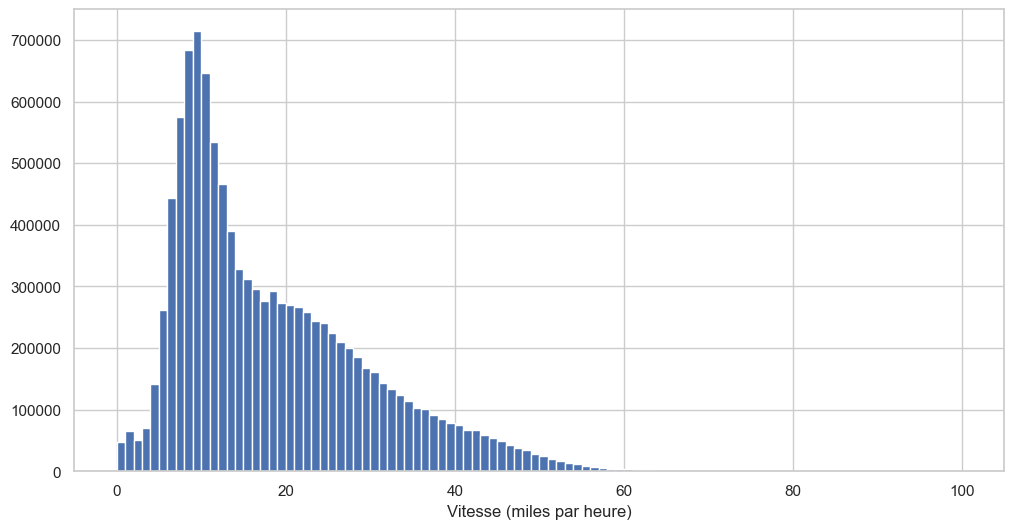

In [68]:
df["speed_mph"] = df["Trip Miles"] / (df["Trip Seconds"]/3600)
print(df["speed_mph"].describe())
plt.hist(df["speed_mph"], bins=100, range=(0,100))
plt.xlabel("Vitesse (miles par heure)")   

Le resultat montre clairement qu'il a des outliers. La vitesse maximale semble aberante, et la min semble peu probable. Pour cela on va defenir des intervalles plutot realiste.

Text(0.5, 0, 'Vitesse (miles par heure)')

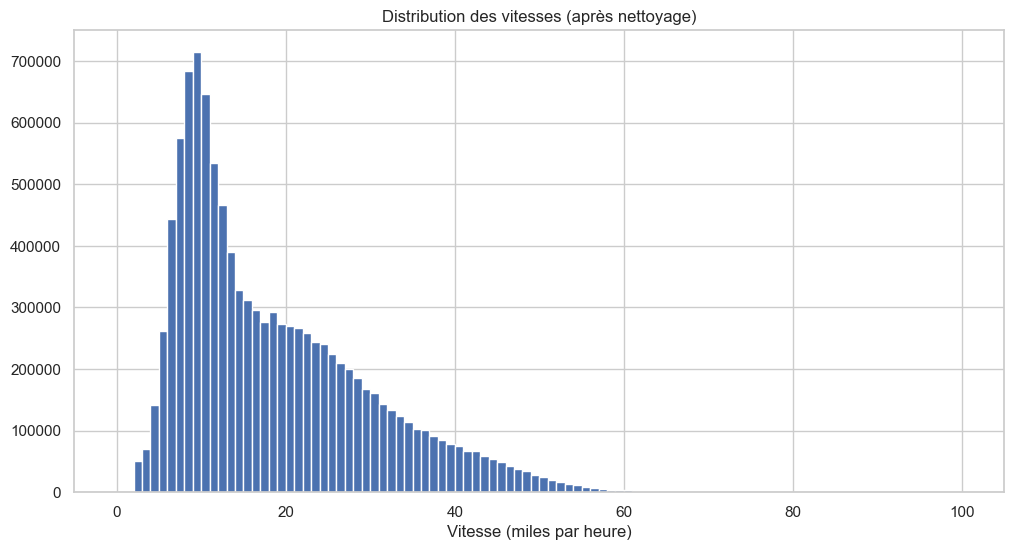

In [69]:
df = df[(df["speed_mph"] <= 200) & (df["speed_mph"] >= 2) ]  # garder trajets entre 2 et 100 mph
plt.title("Distribution des vitesses (après nettoyage)")            
plt.hist(df["speed_mph"], bins=100, range=(0,100))
plt.xlabel("Vitesse (miles par heure)") 


In [70]:
df["speed_mph"].describe()

count   10791709.000
mean          18.567
std           11.313
min            2.000
25%            9.616
50%           15.257
75%           25.250
max          200.000
Name: speed_mph, dtype: float64

#### Trip Miles vs Trip Total : Montant Total vs Distance 

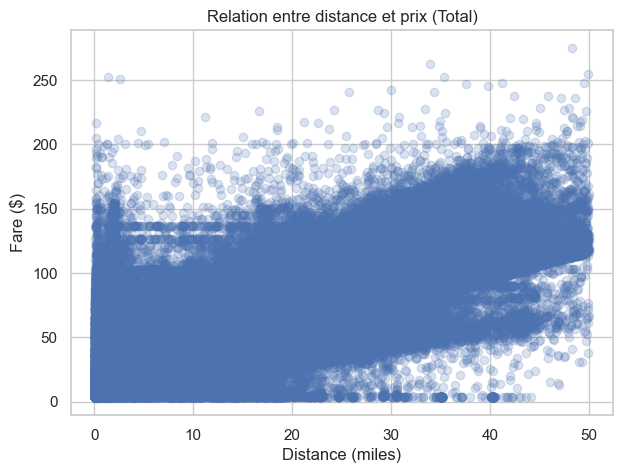

In [71]:
plt.figure(figsize=(7,5))
plt.scatter(df['Trip Miles'], df['Trip Total'], alpha=0.2)
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.title("Relation entre distance et prix (Total)")
plt.show()

 - Résumé : tendance globale positive, le Trip Total augmente en moyenne avec la distance, mais la dispersion est forte.

- Sources de variance supplémentaires : Trip Total inclut Tips, Tolls et Extras ; ces postes expliquent une grande part de la dispersion verticale (mêmes distances peuvent avoir des totaux très différents).
- Outliers / cas suspects : points avec Trip Total élevé pour distance courte (vérifier pourboires/péages/erreurs) ou distance élevée avec Trip Total faible (vérifier cohérence des données)

### Tips vs Payment : Pourboire vs Prix 

In [72]:
df["Tips"].groupby(df["Payment Type"]).describe()

,count,mean,std,min,25%,50%,75%,max
Payment Type,,,,,,,,
Cash,2508194.000,0.001,0.099,0.000,0.000,0.000,0.000,60.000
Credit Card,4137867.000,6.066,4.565,0.000,2.290,5.000,9.500,100.000
Mobile,2322860.000,2.468,2.954,0.000,0.000,2.000,3.090,74.740
Prcard,1414974.000,0.142,0.882,0.000,0.000,0.000,0.000,47.000
Unknown,407814.000,0.004,0.132,0.000,0.000,0.000,0.000,11.500


- Credit Card présente la médiane la plus élevée (~5$) et aussi la moyenne la plus haute (~6.0$).

- Mobile suit avec une médiane autour de 2$ (moyenne ~2.45$).

- Cash, Prcard et Unknown ont une médiane = 0$, ce qui indique que la grande majorité des trajets payés via ces méthodes n’incluent aucun tip

### Correlation entre quelques variables 

In [73]:
# Sélection des variables pertinentes
num_cols = [
    "Trip Miles",
    "Trip Seconds",
    "Fare",
    "Trip Total",
    "Tips",
    "Tolls",
    "Extras"
]

# Garder seulement les colonnes présentes dans ton df
num_cols = [c for c in num_cols if c in df.columns]
df_corr = df[num_cols].astype(float)

corr_matrix = df_corr.corr()
corr_matrix


,Trip Miles,Trip Seconds,Fare,Trip Total,Tips,Tolls,Extras
Trip Miles,1.000,0.754,0.954,0.930,0.537,0.090,0.451
Trip Seconds,0.754,1.000,0.776,0.730,0.426,0.039,0.264
Fare,0.954,0.776,1.000,0.953,0.521,0.083,0.412
Trip Total,0.930,0.730,0.953,1.000,0.692,0.131,0.627
Tips,0.537,0.426,0.521,0.692,1.000,0.080,0.446
Tolls,0.090,0.039,0.083,0.131,0.080,1.000,0.131
Extras,0.451,0.264,0.412,0.627,0.446,0.131,1.000


- En analysant la matrice de corrélation, plusieurs points clés se dégagent :

- La variable la plus déterminante est clairement la distance (Trip Miles), très fortement corrélée au tarif de base Fare (r ≈ 0.95). Cela confirme que le prix dépend principalement du nombre de miles parcourus.

- Trip Total est logiquement très corrélé à Trip Miles et Fare, puisque le montant total correspond au tarif de base auquel s’ajoutent tips, tolls et extras.

- Les pourboires (Tips) montrent une corrélation positive mais plus modérée avec Fare et Trip Total. Les clients ont tendance à laisser des pourboires plus élevés lors de trajets plus longs ou plus chers, mais le comportement reste en partie indépendant.

- Les péages (Tolls) jouent un rôle mineur dans l’explication de la variance : leurs corrélations sont faibles, ce qui montre qu’ils ne concernent qu’un type particulier de trajets.

- Les extras (Extras) présentent une corrélation modérée avec Fare et Trip Total, ce qui reflète leur logique : ils ajoutent des surcharges (nuit, aéroport, etc.) mais n’expliquent pas seuls la structure des prix.

### Distribution des Community Areas pour pickups et dropoffs

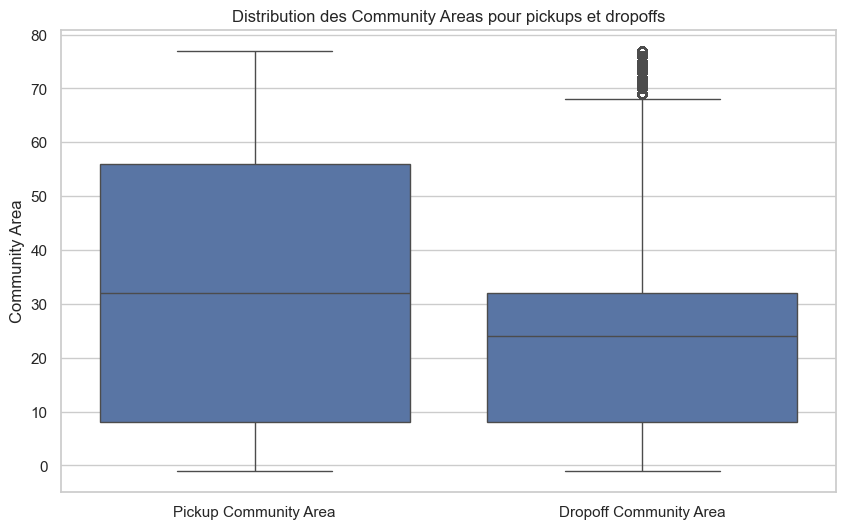

In [74]:
plt.figure(figsize=(10,6))

# On prépare les données pour seaborn
df_box = df[['Pickup Community Area', 'Dropoff Community Area']].melt(
    var_name='Type', value_name='Community Area'
)

# Boxplot
sns.boxplot(x='Type', y='Community Area', data=df_box)
plt.title("Distribution des Community Areas pour pickups et dropoffs")
plt.ylabel("Community Area")
plt.xlabel("")
plt.show()

* Les zones de **pickup** sont plus dispersées, couvrant un éventail plus large de Community Areas que les dropoffs.
* Le pickup montre une plus grande variabilité, ce qui peut révéler des points de départ plus hétérogènes dans la ville.
* Les dropoffs sont plus concentrés autour de valeurs intermédiaires, avec quelques outliers élevés.
* La médiane du pickup est plus haute, indiquant une tendance à partir de zones plus éloignées ou variées.
* Globalement, la distribution suggère que les trajets commencent dans des zones plus diverses qu’ils ne se terminent.


### Courses par heure × zone

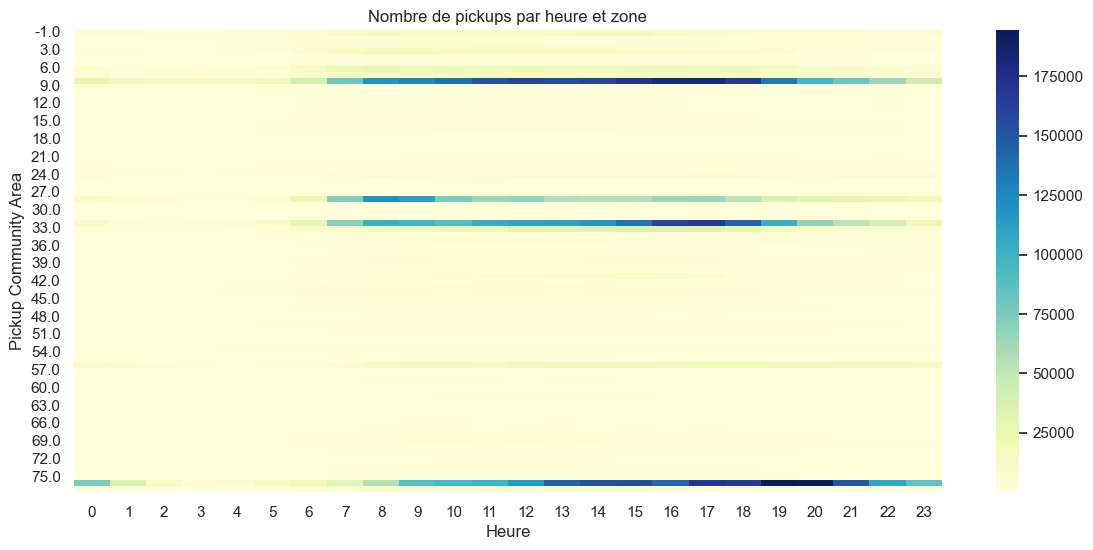

In [75]:
# Grouper par heure et zone
hourly_pickups = df.groupby(['start_hour', 'Pickup Community Area']).size().unstack(fill_value=0)

plt.figure(figsize=(14,6), alpha=0.05)
sns.heatmap(hourly_pickups.T, cmap='YlGnBu')
plt.title("Nombre de pickups par heure et zone")
plt.xlabel("Heure")
plt.ylabel("Pickup Community Area")
plt.show()



- Pattern principal : on observe des bandes horaires visibles, pics de pickups aux heures de pointe (matin & fin d’après‑midi) pour la majorité des zones, et creux la nuit.

- Zones actives vs périphériques : quelques Community Areas montrent des valeurs très élevées sur toute la journée (centre, aéroport), ce sont des hubs persistants ; d’autres ne bougent que sur des plages localisées (zones résidentielles le matin/soir).

- Décalages horaires locaux : certaines zones ont un pic tardif (vie nocturne) ou tôt (départs pour aéroport) ; utile pour repérer rôles fonctionnels des zones.

- Hétérogénéité spatiale : la variance entre zones est large, indique qu’il faut modéliser l’interaction heure × zone (features croisées ou agrégats par zone).

- Bruit et sparsité : de nombreuses zones montrent des valeurs proches de 0 hors leurs plages actives, envisager de regrouper les zones rares en Other pour la modélisation

### Identifier zones courtes/longues et fréquentes/rates

In [76]:
# Calcul distance moyenne et nombre de trajets par zone
zone_stats = df.groupby('Pickup Community Area').agg(
    avg_distance=('Trip Miles', 'mean'),
    num_trips=('Trip ID', 'count')
).reset_index()

In [77]:
# Zones avec trajets courts mais nombreux
short_frequent = zone_stats[(zone_stats['avg_distance'] < zone_stats['avg_distance'].median()) &
                            (zone_stats['num_trips'] > zone_stats['num_trips'].median())]

print("Zones avec trajets courts mais nombreux :")
print(short_frequent[['Pickup Community Area', 'avg_distance', 'num_trips']].head(10))

Zones avec trajets courts mais nombreux :
    Pickup Community Area  avg_distance  num_trips
1                   1.000         8.176      59420
2                   2.000         7.636      75795
3                   3.000         6.266     173913
4                   4.000         5.828      37423
5                   5.000         6.361      24563
6                   6.000         5.176     354462
7                   7.000         4.578     227114
8                   8.000         3.696    2358479
14                 14.000         7.046      18212
16                 16.000         7.928      33612


In [78]:
# Zones avec trajets longs mais rares
long_rare = zone_stats[(zone_stats['avg_distance'] > zone_stats['avg_distance'].median()) &
                       (zone_stats['num_trips'] < zone_stats['num_trips'].median())]

print("\nZones avec trajets longs mais rares :")
print(long_rare[['Pickup Community Area', 'avg_distance', 'num_trips']].head(10))


Zones avec trajets longs mais rares :
    Pickup Community Area  avg_distance  num_trips
9                   9.000         9.312       3252
12                 12.000         9.552      15900
18                 18.000         9.583       1258
26                 26.000        10.385       5079
29                 29.000         9.289      10029
30                 30.000        11.973       5964
37                 37.000         9.718      17624
45                 45.000         9.537      10052
47                 47.000        11.319       4028
48                 48.000         9.898      14061


## 7. Analyse de cohérence et détection d’anomalies
- Identifications anomalies :
  - Trip Seconds = 0 mais distance > 0
  - Fare = 0 mais distance > 0
  - Tolls > 0 pour des trajets courts urbains
- Détection des taxis ayant un comportement atypique :
  - nombre anormalement élevé de courses
  - distances très faibles répétées
  - durées systématiquement élevées

In [79]:
cond_anom = (
    (df["Fare"] == df["Fare"].min()) &
    (df["Trip Miles"] > df["Trip Miles"].mean())
)
cond_anom

0           False
1           False
2           False
3           False
4           False
            ...  
12204106    False
12204107    False
12204108    False
12204109    False
12204110    False
Length: 10791709, dtype: bool

On decide de virer les observation dont le trajet coute le min de Fare et la durée est superieur à la moyenne de Trip Miles car cela semble peu probable.

In [80]:
df = df[~cond_anom]

In [81]:
df[
    (df["Fare"] == df["Fare"].min()) &
    (df["Trip Miles"] > df["Trip Miles"].mean())
]


,Unnamed: 0,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,...,hour_sin,hour_cos,is_night,payment_freq,Payment Simplified,Company_clean,company_freq,pickup_freq,dropoff_freq,speed_mph


Après le traitement on constate que y'a plus d'observation qui respecte cette condition 

In [82]:
# Essayons de creer les sin et cos de weekday 
df['weekday_sin'] = np.sin(2 * np.pi * df['start_weekday']/7)  
df['weekday_cos'] = np.cos(2 * np.pi * df['start_weekday']/7)

# Essayons de creer les sin et cos de weekday 
df['month_sin'] = np.sin(2 * np.pi * (df['start_month']-1) / 12) # Sinon, janvier (1) et décembre (12) ne seront pas exactement voisins sur le cercle.
df['month_cos'] = np.cos(2 * np.pi * (df['start_month']-1) / 12)

In [83]:
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df.to_parquet("../data/df_taxi_parquet.parquet")

<h1 style="color:#ff4d4d; font-weight:bold; text-align:center;">
Modélisation
</h1>


## <span style="color:#1e90ff;">Modélisation de Fare avec ElasticNet</span>

In [87]:
df_elasitc_net = pd.read_parquet("../data/df_taxi_parquet.parquet")

## Ridge Regression (L2)

$$
\hat{\beta} 
= \arg\min_{\beta} 
\left\{
\sum_{i=1}^n (y_i - X_i \beta)^2 
\;+\; \lambda \sum_{j=1}^p \beta_j^2
\right\}
$$

---

## Lasso Regression (L1)

$$
\hat{\beta} 
= \arg\min_{\beta} 
\left\{
\sum_{i=1}^n (y_i - X_i \beta)^2 
\;+\; \lambda \sum_{j=1}^p |\beta_j|
\right\}
$$

---

## Elastic Net (L1 + L2)

$$
\hat{\beta}
= \arg\min_{\beta}
\left\{
\sum_{i=1}^n (y_i - X_i \beta)^2
\;+\; \lambda \left[
\alpha \sum_{j=1}^p |\beta_j|
\;+\; (1 - \alpha) \sum_{j=1}^p \beta_j^2
\right]
\right\}
$$


In [88]:
df_elasitc_net.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10791703 entries, 0 to 12204110
Data columns (total 36 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Unnamed: 0              int64         
 1   Trip ID                 object        
 2   Taxi ID                 object        
 3   Trip Start Timestamp    datetime64[ns]
 4   Trip End Timestamp      datetime64[ns]
 5   Trip Seconds            float64       
 6   Trip Miles              float64       
 7   Pickup Community Area   float64       
 8   Dropoff Community Area  float64       
 9   Fare                    float64       
 10  Tips                    float64       
 11  Tolls                   float64       
 12  Extras                  float64       
 13  Trip Total              float64       
 14  Payment Type            object        
 15  Company                 object        
 16  start_hour              int32         
 17  start_weekday           int32         
 18  start

In [89]:
X_final = [
    # Ride features (connues avant la course)
    "Trip Miles",  
    "Trip Seconds",          
    "start_hour",
    "start_weekday",
    "start_month",
    "is_weekend",
    "is_night",

    # Cyclical encodings
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",

    # Frequencies (proxies de demande/offre)
    "pickup_freq",
    "dropoff_freq",
    "company_freq"
    # "payment_freq",


]

target = "Fare"

variables_exclues = {
    "speed_mph": "Vitesse réelle calculée après la course, impossible à connaître en amont.",
    "Trip Total": "Inclus dynamiquement les tips, les extras et les ajustements post-course.",
    "Tolls": "Les péages réellement empruntés ne sont connus qu'après la course.",
    "Tips": "Variable déterminée par le client à la fin de la course.",
    "Extras": "Inclut suppléments appliqués en fin de course (fuel surcharge, bagages…).",
    "Company": "Trop de catégories → remplacé par company_freq (plus scalable).",
    "Pickup Community Area": "Trop de modalités → remplacé par pickup_freq.",
    "Dropoff Community Area": "Trop de modalités → remplacé par dropoff_freq.",
    "Payment Type": "Trop de catégories → remplacé par Payment Simplified + payment_freq.",
    "period_of_day": "Redondant avec start_hour et is_night.",
}

- Les variables liées au déroulement réel de la course (durée, vitesse, péages, pourboires, suppléments) ont été exclues afin d’éviter toute fuite d’information (data leakage).
- Dans une perspective de prédiction du tarif avant la course, seules les informations réellement disponibles au moment du pickup ont été conservées.

#### ÉCHANTILLON DE 1 MILLION:

In [90]:
df_1m = df_elasitc_net.sample(n=1_000_000, random_state=42)

# Stratification en 10 quantiles
df_1m["fare_strata"] = pd.qcut(df_1m[target], q=10, duplicates='drop').cat.codes

- Un échantillon aléatoire de 1 000 000 observations est extrait du dataset complet afin de réduire la charge computationnelle. Cet échantillonnage permet de conserver une représentativité statistique tout en rendant la cross-validation possible sur une machine locale.
- Pour assurer une répartition équilibrée de la variable cible dans les différents jeux d'entraînement et de validation, la variable Fare est transformée en classes via un découpage en déciles (10 quantiles). pd.qcut crée des intervalles, puis .cat.codes les convertit en entiers exploitables par les méthodes de stratification.
- Cette stratification est utilisée lors du split train/test et lors de la cross-validation, ce qui garantit que chaque sous-ensemble possède une distribution similaire de valeurs de Fare. Cela stabilise les estimations des performances et évite que certains folds contiennent uniquement des trajets très peu chers ou très chers.
- Cette procédure est cohérente avec la liste des variables explicatives X_final : la stratification porte uniquement sur la variable cible Fare et ne crée aucun risque de fuite d'information, et l’échantillonnage n’altère pas les propriétés des features retenues pour la modélisation Elastic Net

<Axes: xlabel='Fare', ylabel='Density'>

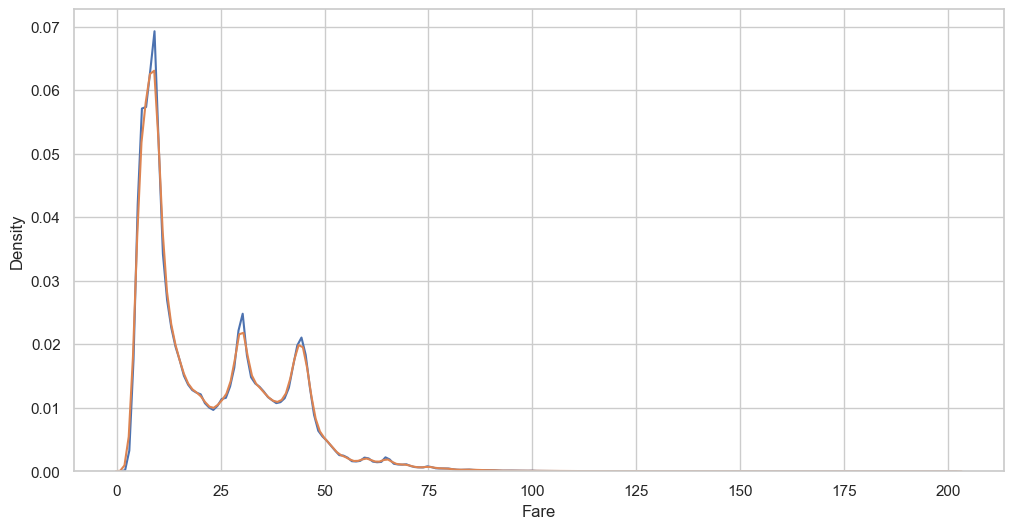

In [91]:
sns.kdeplot(data=df_elasitc_net, x=target)
sns.kdeplot(data=df_1m, x=target)

#### TRAIN / TEST SPLIT (STRATIFIÉ) :

In [92]:
X_small = df_1m[X_final]
y_small = df_1m[target]
strata = df_1m["fare_strata"]

X_train_small, X_test_small, y_train_small, y_test_small, strata_train, strata_test = train_test_split(
    X_small,
    y_small,
    strata,
    test_size=0.2,
    random_state=42,
    stratify=strata
)

- Extraction du jeu de features X_small à partir des variables explicatives retenues (X_final).
- Définition de la variable cible y_small correspondant à Fare.
- Récupération de la variable de stratification strata, qui représente les quantiles du prix et permet de garantir l’équilibre des distributions de la cible dans les différents sous-échantillons.
- Séparation de l’échantillon d’un million d’observations en un jeu d’entraînement (80 %) et un jeu de test (20 %).
- La stratification est réalisée à l’aide de la variable strata, ce qui impose que les distributions des quantiles de Fare soient similaires dans les deux sous-échantillons.
- Le résultat contient les données explicatives et cibles pour l’entraînement et le test, ainsi que les variables de stratification correspondantes, utiles pour des vérifications éventuelles.

#### SCALING :

In [93]:
scaler = StandardScaler()
X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_small_scaled = scaler.transform(X_test_small)

In [94]:
alphas = [0.0005, 0.001, 0.01, 0.1]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

strata_train_q = pd.qcut(y_train_small, q=10, duplicates="drop").cat.codes

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_rmse = float("inf")
best_alpha = None
best_l1 = None
best_r2_cv = None
best_mae_cv = None

for a in alphas:
    for l1 in l1_ratios:
        rmses = []
        r2s = []
        maes = []

        for train_idx, val_idx in kf.split(X_train_small_scaled, strata_train_q):
            X_tr = X_train_small_scaled[train_idx]
            X_val = X_train_small_scaled[val_idx]
            y_tr = y_train_small.iloc[train_idx]
            y_val = y_train_small.iloc[val_idx]

            model = ElasticNet(alpha=a, l1_ratio=l1, max_iter=20000)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_val)

            rmses.append(root_mean_squared_error(y_val, pred))
            r2s.append(r2_score(y_val, pred))
            maes.append(mean_absolute_error(y_val, pred))

        avg_rmse = np.mean(rmses)
        avg_r2 = np.mean(r2s)
        avg_mae = np.mean(maes)

        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_alpha = a
            best_l1 = l1
            best_r2_cv = avg_r2
            best_mae_cv = avg_mae



- Une grille de valeurs possibles est définie pour les hyperparamètres d’Elastic Net : alpha (force de régularisation) et l1_ratio (poids entre L1 et L2).
- La variable cible du jeu d’entraînement est découpée en 10 quantiles afin de créer une stratification utilisable par StratifiedKFold. Cette stratification garantit que chaque fold contient une distribution similaire de valeurs de Fare.
- Une cross-validation à 5 folds est définie : à chaque itération, un fold sert de validation et les quatre autres d’entraînement.
- Pour chaque combinaison (alpha, l1_ratio), le modèle Elastic Net est entraîné sur les folds d’entraînement et évalué sur le fold de validation.
- Trois métriques sont calculées sur chaque fold : RMSE, R² et MAE. On stocke ensuite leur moyenne sur les 5 folds.
- La combinaison d’hyperparamètres qui minimise la moyenne des RMSE est conservée comme la meilleure, et les métriques correspondantes (R² moyen et MAE moyen) sont également enregistrées.

#### TRAIN METRICS :

In [95]:
print("\n===== CROSS-VALIDATION RESULTS =====")
print("Best alpha :", best_alpha)
print("Best l1_ratio :", best_l1)
print("Best CV RMSE :", best_rmse)
print("Best CV MAE :", best_mae_cv)
print("Best CV R²  :", best_r2_cv)

# ===== FINAL SCALING (propre) =====
final_scaler = StandardScaler()
X_train_small_scaled = final_scaler.fit_transform(X_train_small)  # fit sur tout le train
X_test_small_scaled  = final_scaler.transform(X_test_small)       # transform sur test

# ===== FINAL MODEL FIT =====
best_model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=20000)
best_model.fit(X_train_small_scaled, y_train_small)

# ===== TRAIN METRICS =====
y_pred_train = best_model.predict(X_train_small_scaled)

rmse_train = root_mean_squared_error(y_train_small, y_pred_train)
mae_train = mean_absolute_error(y_train_small, y_pred_train)
r2_train = r2_score(y_train_small, y_pred_train)

print("\n===== TRAIN METRICS =====")
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("R² :", r2_train)

# ===== TEST METRICS =====
y_pred_test = best_model.predict(X_test_small_scaled)

rmse_test = root_mean_squared_error(y_test_small, y_pred_test)
mae_test = mean_absolute_error(y_test_small, y_pred_test)
r2_test = r2_score(y_test_small, y_pred_test)

print("\n===== TEST METRICS =====")
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("R² :", r2_test)


===== CROSS-VALIDATION RESULTS =====
Best alpha : 0.001
Best l1_ratio : 0.9
Best CV RMSE : 4.755595254526425
Best CV MAE : 1.8598397085368876
Best CV R²  : 0.918131867799867

===== TRAIN METRICS =====
RMSE: 4.754748702810456
MAE: 1.8596342976679172
R² : 0.9181639850546917

===== TEST METRICS =====
RMSE: 4.765924810411635
MAE: 1.8634151131168772
R² : 0.9175398660275362


- Le paramètre alpha = 0.001 indique une régularisation très faible. Une valeur basse est cohérente avec un dataset très volumineux : plus le nombre d’observations est grand, plus le modèle peut apprendre des relations stables sans nécessiter une forte pénalisation. Un alpha élevé aurait sous-ajusté le modèle en supprimant trop de variance utile.

- Le paramètre l1_ratio = 0.9 montre que l’Elastic Net applique principalement une régularisation de type L1 (lasso). Cela signifie que le modèle privilégie la sélection de variables en mettant certains coefficients proches de zéro. Dans ce contexte, où seules des variables pertinentes et peu corrélées ont été retenues dans X_final, il est logique que la partie L1 domine, car elle stabilise le modèle tout en conservant un ensemble restreint de coefficients significatifs.

- La combinaison alpha faible et l1_ratio élevé est cohérente pour un modèle linéaire entraîné sur un grand volume de données avec peu de bruit structurel : la régularisation n’est pas trop forte pour permettre un bon ajustement, mais suffisamment orientée L1 pour éviter des coefficients instables ou non pertinents.

**Enregistrer les resultats :**

In [96]:
results = {
    "model": "ElasticNet",
    "best_params": {
        "alpha": best_alpha,
        "l1_ratio": best_l1
    },
    "cv_metrics": {
        "rmse": best_rmse,
        "mae": best_mae_cv,
        "r2": best_r2_cv
    },
    "train_metrics": {
        "rmse": rmse_train,
        "mae": mae_train,
        "r2": r2_train
    },
    "test_metrics": {
        "rmse": rmse_test,
        "mae": mae_test,
        "r2": r2_test
    }
}

with open("./resultat/results_elasticnet.json", "w") as f:
    json.dump(results, f, indent=4)



In [97]:
coefs = best_model.coef_


importance = np.abs(coefs)

feat_imp = pd.DataFrame({
    "feature": X_train_small.columns,
    "coef": coefs,
    "importance": importance
})

feat_imp = feat_imp.sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,coef,importance
0,Trip Miles,14.057,14.057
1,Trip Seconds,2.331,2.331
13,pickup_freq,-0.272,0.272
15,company_freq,0.237,0.237
6,is_night,0.147,0.147
8,hour_cos,0.124,0.124
3,start_weekday,0.071,0.071
12,month_cos,-0.052,0.052
2,start_hour,-0.051,0.051
11,month_sin,-0.044,0.044


Cela permet d’extraire et analyser les coefficients estimés par le modèle ElasticNet, qui sont l’estimation de l’effet de chaque variable explicative sur la variable cible y.

C:\Users\maserati\AppData\Local\Temp\ipykernel_16748\2810601882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


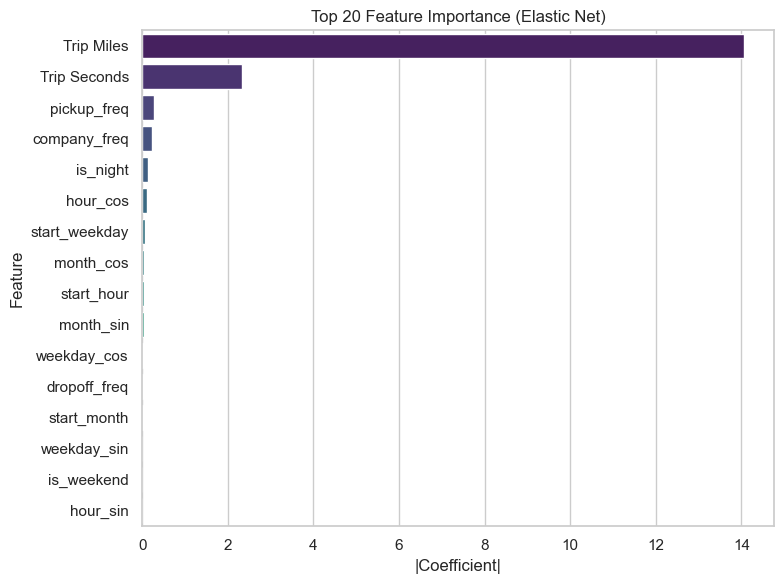

In [98]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp.head(20),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 Feature Importance (Elastic Net)")
plt.xlabel("|Coefficient|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- Les deux variables les plus importantes sont Trip Miles et Trip Seconds. Trip Miles domine largement le modèle, ce qui est cohérent car la distance est le déterminant structurel du prix d’une course, tandis que Trip Seconds apporte une information complémentaire liée au temps passé dans le trafic.

- Les variables de fréquence (pickup_freq, company_freq, dropoff_freq) occupent une place significative, ce qui indique que certains points de départ, compagnies ou zones de dépose sont associés à des trajets typiquement plus longs ou plus coûteux.

- Les variables temporelles (is_night, start_hour, is_weekend, month_sin/cos) ont une importance modérée mais réelle. Cela confirme que l’heure et la période influencent les conditions de circulation ou les habitudes de déplacement, ce qui affecte le prix via la durée et la distance.

- Les encodages sinusoïdaux pour les heures et les mois apportent un complément d’information mais restent moins influents que les variables brutes. Enfin, les variables liées au jour de la semaine (weekday_sin/cos) ont une importance très faible, ce qui montre que le jour précis importe peu une fois que les autres variables sont prises en compte.

- Dans l’ensemble, l’importance des variables est cohérente avec la logique du problème : la distance et la durée expliquent l’essentiel, les variables de fréquence ajoutent une structure comportementale, et le contexte temporel affine la prédiction de manière secondairee.

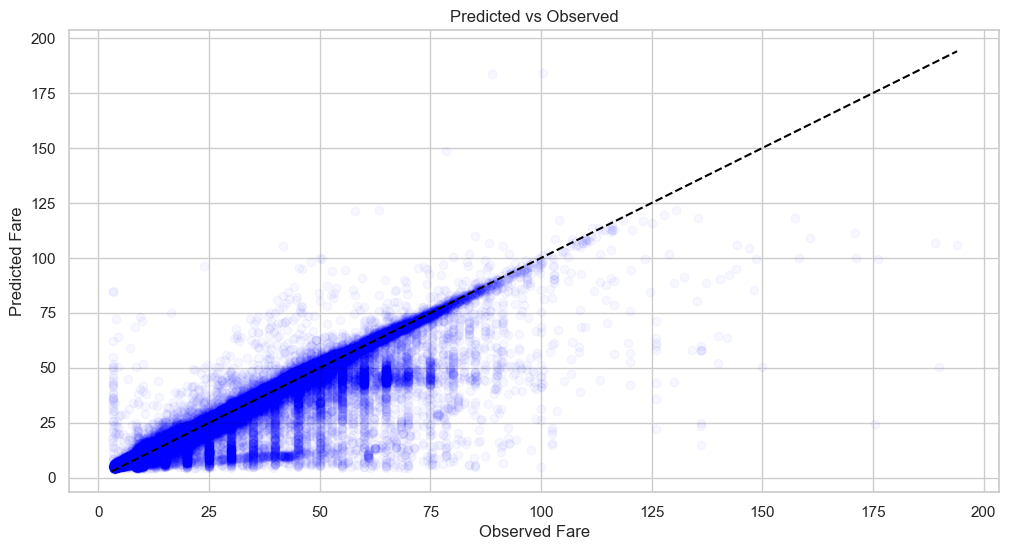

In [99]:
plt.figure(figsize=(12,6))
plt.scatter(y_test_small, y_pred_test, alpha=0.03,c="blue")

# ligne 45° pour repère
min_val = min(y_test_small.min(), y_pred_test.min())
max_val = max(y_test_small.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--",c="black")

plt.xlabel("Observed Fare")
plt.ylabel("Predicted Fare")
plt.title("Predicted vs Observed")
plt.grid(True)
plt.show()

les points du graphique représentent les prédictions, positionnées en fonction des valeurs vraies sur l’axe X.

## <span style="color:#1e90ff;">Modelisation de Fare avec Random Forest Regressor</span> 

1) Pourquoi un Random Forest ?

J’ai choisi d’utiliser un Random Forest Regressor pour prédire le prix d’un trajet de taxi.
C’est un modèle robuste, très performant sur les grands datasets, et qui gère bien les relations non linéaires comme :

- distance × durée

- zone de départ / d’arrivée

- heures de la journée

- comportements des compagnies

Il ne demande pas de normalisation, gère les interactions automatiquement, et résiste bien au surapprentissage

#### Tuning des hyperparamètres avec RandomizedSearchCV

Comme j’ai un dataset de 10 millions de lignes, je ne peux pas tester toutes les combinaisons d’hyperparamètres (GridSearch serait beaucoup trop long).

J’ai donc utilisé RandomizedSearchCV sur un sample de 500 000 lignes.

RandomizedSearchCV = outil qui choisit automatiquement de bons hyperparamètres.
Il teste plusieurs combinaisons au hasard, les évalue en cross-validation interne et garde la meilleure.

C’est rapide, efficace et parfait pour les gros datasets

In [ ]:
sample_idx = np.random.choice(X_train.index, size=500_000, replace=False)
X_train = X_train.loc[sample_idx]
y_train = y_train.loc[sample_idx]

param_distributions = {
    "max_depth": [10, 12, 14, 16],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt"],
    "n_estimators": [40]
}

rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    bootstrap=True
)

cv = KFold(n_splits=2, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=10,   # -> teste 10 combinaisons aléatoires
    scoring="neg_root_mean_squared_error",
    cv=cv,       # -> cross-validation interne 2-fold
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_params = random_search.best_params_

#### Construction du modèle final avec les bons paramètres

À partir du tuning, j’ai construit le modèle final avec un compromis :

- assez performant

- mais rapide à entraîner sur 10 millions de lignes

qui généralise bien

Hyperparamètres finaux :

- n_estimators = 100 → assez d’arbres pour stabiliser

- max_depth = 14 → limite la complexité (évite overfitting)

- min_samples_split = 5

- min_samples_leaf = 2 → feuilles plus stables

- max_features = "sqrt" → arbres plus variés

- max_samples = 0.7 → chaque arbre voit seulement 70% du train (plus rapide, plus robuste)

- bootstrap = True

Adapté au volume massif du dataset et aux contraintes de calcul.

In [100]:
# =====================================================
# 0. Définition des features et de la cible
#    (Dans cette partie, on précise les variables qui
#    serviront au modèle + la cible Fare.)
# =====================================================

target = "Fare"

features_to_keep = [
    "Trip Miles",
    "Trip Seconds",
    "Pickup Community Area",
    "Dropoff Community Area",
    "pickup_freq",
    "dropoff_freq",
    "company_freq",
    "start_hour",
    "start_weekday",
    "start_month",
    "is_weekend",
    "hour_sin",
    "hour_cos"
    
    
]

X = df[features_to_keep].copy()
y = df[target].copy()

print("Shape total :", X.shape)

# =====================================================
# 1. Split TRAIN / TEST sur toute la base
#    (Ici on fait un split 80% / 20%, le test sera
#    utilisé seulement à la fin pour évaluer le modèle.)
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Shape train :", X_train.shape)
print("Shape test  :", X_test.shape)

Shape total : (10791703, 13)
Shape train : (8633362, 13)
Shape test  : (2158341, 13)


In [101]:

# =====================================================
# 2. Définition et entraînement du Random Forest
#    (On choisit des hyperparamètres raisonnables mais
#    rapides pour 10M de lignes : moins d'arbres,
#    profondeur limitée et sous-échantillonnage.)
# =====================================================

rf = RandomForestRegressor(
    n_estimators=100,       # 100 arbres pour aller vite
    max_depth=14,         # profondeur raisonnable
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    max_samples=0.7,      # chaque arbre voit 60% du train -> gros gain de temps
    n_jobs=-1,
    random_state=42,
    bootstrap=True
)

print("\n>>> Entraînement du Random Forest sur tout le TRAIN...")
rf.fit(X_train, y_train)


>>> Entraînement du Random Forest sur tout le TRAIN...


,n_estimators,100
,criterion,'squared_error'
,max_depth,14
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Cross-validation indépendante pour valider la stabilité du modèle

Après avoir déterminé les meilleurs hyperparamètres grâce au RandomizedSearchCV, j’ai réalisé une cross-validation indépendante sur un échantillon de 500 000 lignes, en 2 folds. Le but est différent du tuning : RandomizedSearchCV sert uniquement à trouver les bons hyperparamètres, alors que cette seconde CV sert à évaluer la stabilité du modèle final. En comparant les résultats de cette CV avec ceux du train et du test, on constate des performances très proches, ce qui montre que le modèle est cohérent, régulier et ne présente pas d’overfitting.

In [104]:
# =====================================================
# 3. Métriques sur le TRAIN
#    (Dans cette partie on mesure la qualité sur les
#    données vues pendant l'entraînement.)
# =====================================================

y_pred_train = rf.predict(X_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("\n===== TRAIN =====")
print(f"MAE  : {mae_train}")
print(f"RMSE : {rmse_train}")
print(f"R²   : {r2_train}")


# =====================================================
# 4. Cross-validation 2-fold sur un petit sample du TRAIN
#    (Ici on prend 5% du train, limité à 200k lignes,
#    pour faire une CV 2-fold avec un modèle plus léger.
#    Objectif : vérifier la stabilité sans exploser le temps.)
# =====================================================

cv_frac = 0.10       # 10% du train
cv_max_rows = 500_000   # plafond dur

n_cv = int(min(len(X_train) * cv_frac, cv_max_rows))
cv_idx = np.random.choice(X_train.index, size=n_cv, replace=False)

X_cv = X_train.loc[cv_idx]
y_cv = y_train.loc[cv_idx]

print("\nSample utilisé pour la CV :", X_cv.shape)

kf = KFold(n_splits=2, shuffle=True, random_state=42)

y_cv_true_all = []
y_cv_pred_all = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_cv), start=1):
    X_tr, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    y_tr, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
    
    # Modèle  pour la CV 
    rf_cv = RandomForestRegressor(
        n_estimators=100,
        max_depth=14,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        max_samples=0.7,
        n_jobs=-1,
        random_state=42 + fold,  # léger changement pour chaque fold
        bootstrap=True
    )
    
    rf_cv.fit(X_tr, y_tr)
    y_val_pred = rf_cv.predict(X_val)
    
    y_cv_true_all.append(y_val.values)
    y_cv_pred_all.append(y_val_pred)

# On concatène toutes les prédictions des 2 folds
y_cv_true_all = np.concatenate(y_cv_true_all)
y_cv_pred_all = np.concatenate(y_cv_pred_all)

mae_cv = mean_absolute_error(y_cv_true_all, y_cv_pred_all)
rmse_cv = np.sqrt(mean_squared_error(y_cv_true_all, y_cv_pred_all))
r2_cv = r2_score(y_cv_true_all, y_cv_pred_all)

print("\n===== CROSS-VALIDATION (2-fold, sample TRAIN) =====")
print(f"MAE  : {mae_cv}")
print(f"RMSE : {rmse_cv}")
print(f"R²   : {r2_cv}")

# =====================================================
# 5. Métriques sur le TEST
#    (Enfin, on évalue le modèle entraîné au §2 sur
#    le jeu de test mis de côté au début. C'est la vraie
#    performance de généralisation.)
# =====================================================

y_pred_test = rf.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n===== TEST =====")
print(f"MAE  : {mae_test}")
print(f"RMSE : {rmse_test}")
print(f"R²   : {r2_test}")



===== TRAIN =====
MAE  : 1.673470645728023
RMSE : 4.076465586076948
R²   : 0.9398159023559397

Sample utilisé pour la CV : (500000, 13)

===== CROSS-VALIDATION (2-fold, sample TRAIN) =====
MAE  : 1.7568736892609704
RMSE : 4.29627423962704
R²   : 0.9330045758863389

===== TEST =====
MAE  : 1.7007393594820561
RMSE : 4.188759894407597
R²   : 0.9364604607250339


                   feature  importance
0               Trip Miles       0.477
1             Trip Seconds       0.273
2    Pickup Community Area       0.117
5             dropoff_freq       0.043
3   Dropoff Community Area       0.040
4              pickup_freq       0.036
6             company_freq       0.004
7               start_hour       0.003
12                hour_cos       0.003
11                hour_sin       0.002
8            start_weekday       0.001
9              start_month       0.001
10              is_weekend       0.000


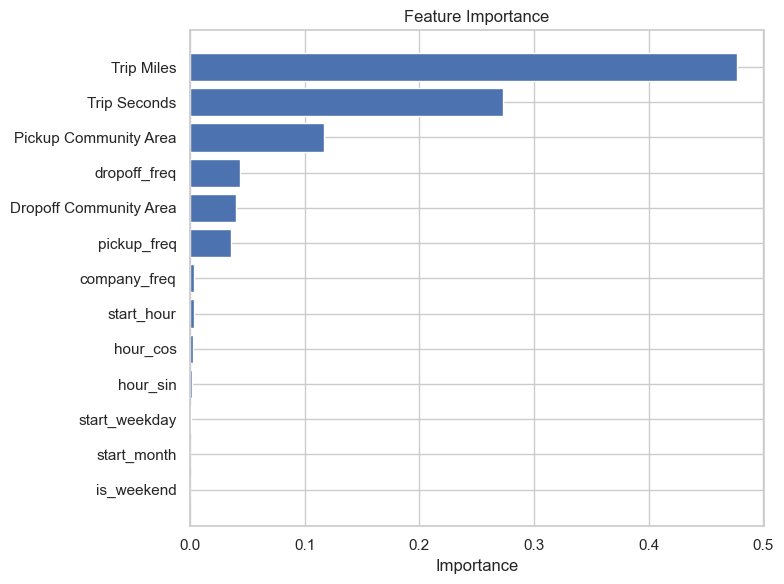

In [105]:
# Récupération des importances
importances = rf.feature_importances_
feature_names = features_to_keep

# DataFrame trié des importances
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp)

#  : visualisation
plt.figure(figsize=(8, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## <span style="color:#1e90ff;">Modélisation de Fare avec XGBOOST </span>


XGBoost (eXtreme Gradient Boosting) est un algorithme d'ensemble basé sur le gradient 
boosting qui construit séquentiellement des arbres de décision pour corriger les erreurs 
des arbres précédents. À chaque itération, un nouvel arbre est entraîné sur les résidus 
(erreurs) du modèle actuel, et sa prédiction est ajoutée au modèle avec un poids 
d'apprentissage. 

Le modèle final combine les prédictions de tous les arbres de manière 
additive. XGBoost est particulièrement performant grâce à ses techniques de régularisation 
qui préviennent le surapprentissage et son optimisation parallèle qui accélère 
l'entraînement. On a fait le choix de cet algorithme en raison de sa précision, sa rapidité et sa robustesse notamment sur des données tabulaires. 

In [106]:
features = [
    'Trip Seconds',
    'Trip Miles',
    #'Pickup Community Area',
    #'Dropoff Community Area',
    #'start_hour',     
    "hour_sin",
    "hour_cos",
    'start_weekday', # à encodder par sin et cos
    'start_month', # à encodder par in et cos
    'is_weekend',  # deja encodder 
    #'is_night'
    'period_of_day',
    # 'payment_freq',
    'company_freq',
    'pickup_freq',
    'dropoff_freq'
]

Pourquoi company_freq et pas company_clean ? 

- company_freq est : une variable numérique unique qui encode la popularité de la compagnie corrélée à son importance réelle dans le dataset simple, compacte, non sparse

- XGBoost va naturellement apprendre :
    - si les grosses compagnies facturent plus ou moins
    - si certaines compagnies tournent plus dans certaines zones
    - si la distance, durée, zones interagissent différemment selon la compagnie


In [107]:
# Essayons de creer les sin et cos de weekday 
df['weekday_sin'] = np.sin(2 * np.pi * df['start_weekday']/7)  
df['weekday_cos'] = np.cos(2 * np.pi * df['start_weekday']/7)

# Essayons de creer les sin et cos de weekday 
df['month_sin'] = np.sin(2 * np.pi * (df['start_month']-1) / 12) # Sinon, janvier (1) et décembre (12) ne seront pas exactement voisins sur le cercle.
df['month_cos'] = np.cos(2 * np.pi * (df['start_month']-1) / 12)


In [108]:
# Features finales utilisées pour le modèle XGBOOST
features = [
    'Trip Seconds',
    'Trip Miles',
    #'Pickup Community Area',
    #'Dropoff Community Area',
    #'start_hour',     
    "hour_sin",
    "hour_cos",
    #"start_weekday",
    "weekday_sin",
    'weekday_cos', 
    #'start_month', 
    "month_sin", 
    "month_cos",
    'is_weekend',  # deja encodder 
    #'is_night'
    'period_of_day',
    # 'payment_freq',
    'company_freq',
    'pickup_freq',
    'dropoff_freq'
]

In [109]:
X = df[features]
y = df["Fare"]
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [ ]:
sample_frac = 0.1  # On va utiliser 10% du train pour aller plus vite
X_train_sample = X_train.sample(frac=sample_frac, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# ============================================================
#               GRID SEARCH XGBOOST
# ============================================================

param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1, 0.5],
    "max_depth": [5, 7, 9],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8]
}

model_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    random_state=42
)

kf = KFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_base,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1
)

print("\n===== GRID SEARCH EN COURS... =====")
grid_search.fit(X_train_sample, y_train_sample)

print("\n===== MEILLEURS PARAMETRES =====")
print(grid_search.best_params_)


===== GRID SEARCH EN COURS... =====
Fitting 3 folds for each of 72 candidates, totalling 216 fits

===== MEILLEURS PARAMETRES =====
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
# ============================================================
#         ENTRAINEMENT FINAL AVEC LES MEILLEURS PARAMS
# ============================================================

best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)
pred_train = best_model.predict(X_train)

print("\n===== TRAIN =====")
print("MAE :", mean_absolute_error(y_train, pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, pred_train)))
print("R²  :", r2_score(y_train, pred_train))

# ============================================================
#            CROSS-VALIDATION (5-fold)
# ============================================================

kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = -cross_val_score(
    best_model, X_train_sample, y_train_sample,
    cv=kf_cv, scoring="neg_mean_absolute_error"
)

rmse_scores = np.sqrt(-cross_val_score(
    best_model, X_train_sample, y_train_sample,
    cv=kf_cv, scoring="neg_mean_squared_error"
))

r2_scores = cross_val_score(
    best_model, X_train_sample, y_train_sample,
    cv=kf_cv, scoring="r2"
)

print("\n===== CROSS-VALIDATION (5-fold) =====")
print("MAE :", mae_scores.mean())
print("RMSE:", rmse_scores.mean())
print("R²  :", r2_scores.mean())

# ============================================================
#                     TEST
# ============================================================

pred_test = best_model.predict(X_test)

print("\n===== TEST =====")
print("MAE :", mean_absolute_error(y_test, pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))
print("R²  :", r2_score(y_test, pred_test))

In [119]:
# ===== MODELE XGBOOST =====
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",  # plus rapide pour grands datasets
    enable_categorical=True,
    random_state=42
)

# ===== TRAIN =====
model.fit(X_train, y_train)
pred_train = model.predict(X_train)

print("===== TRAIN =====")
print("MAE :", mean_absolute_error(y_train, pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, pred_train)))
print("R²  :", r2_score(y_train, pred_train))

# ===== CROSS-VALIDATION (2-fold, échantillon pour accélérer) =====
# Sous-échantillon pour réduire le temps de CV
sample_frac = 0.5  # 10% du train
X_train_sample = X_train.sample(frac=sample_frac, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = -cross_val_score(model, X_train_sample, y_train_sample,
                              cv=kf, scoring='neg_mean_absolute_error')
rmse_scores = np.sqrt(-cross_val_score(model, X_train_sample, y_train_sample,
                                       cv=kf, scoring='neg_mean_squared_error'))
r2_scores = cross_val_score(model, X_train_sample, y_train_sample, cv=kf, scoring='r2')

print("\n===== CROSS-VALIDATION (2-fold, 10% train sample) =====")
print("MAE :", mae_scores.mean())
print("RMSE:", rmse_scores.mean())
print("R²  :", r2_scores.mean())

# ===== TEST =====
pred_test = model.predict(X_test)
print("\n===== TEST =====")
print("MAE :", mean_absolute_error(y_test, pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))
print("R²  :", r2_score(y_test, pred_test))

===== TRAIN =====
MAE : 1.6076399548248284
RMSE: 4.157356372911562
R²  : 0.9373924411358694

===== CROSS-VALIDATION (2-fold, 10% train sample) =====
MAE : 1.622800356972375
RMSE: 4.212003879218889
R²  : 0.935779121018921

===== TEST =====
MAE : 1.6105942996380724
RMSE: 4.1696229936015525
R²  : 0.937072459067217


### Plot réelle vs prédiction XGboost 

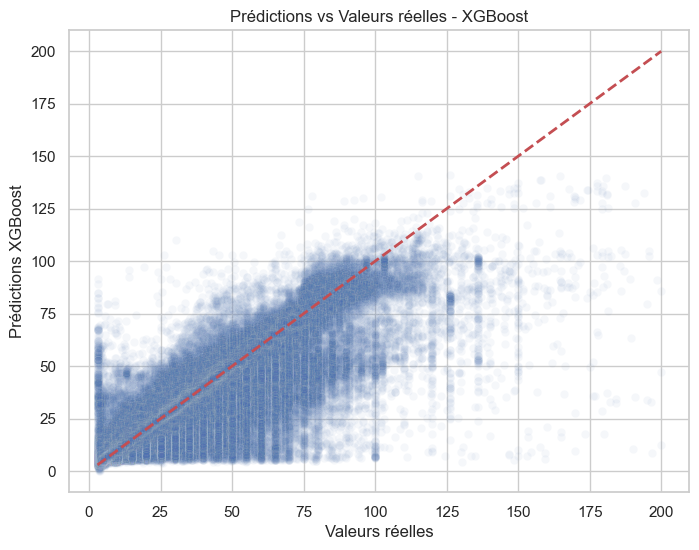

In [120]:
# ===== Scatter plot : prédictions vs réelles =====
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=pred_test, alpha=0.05)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  # ligne y=x
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions XGBoost")
plt.title("Prédictions vs Valeurs réelles - XGBoost")
plt.show()


Le graphique montre une bonne corrélation globale entre les valeurs prédites et les 
valeurs réelles, avec les points concentrés principalement le long de la ligne rouge 
diagonale (y=x) qui représente une prédiction parfaite

In [121]:
explainer = shap.Explainer(model)
rng = np.random.default_rng(seed=78512)
sample = rng.choice(X_test.index, size=int(len(X_test)* 0.01), replace=False)
X_test_sample = X_test.loc[sample, :]
shap_values = explainer.shap_values(X_test_sample)

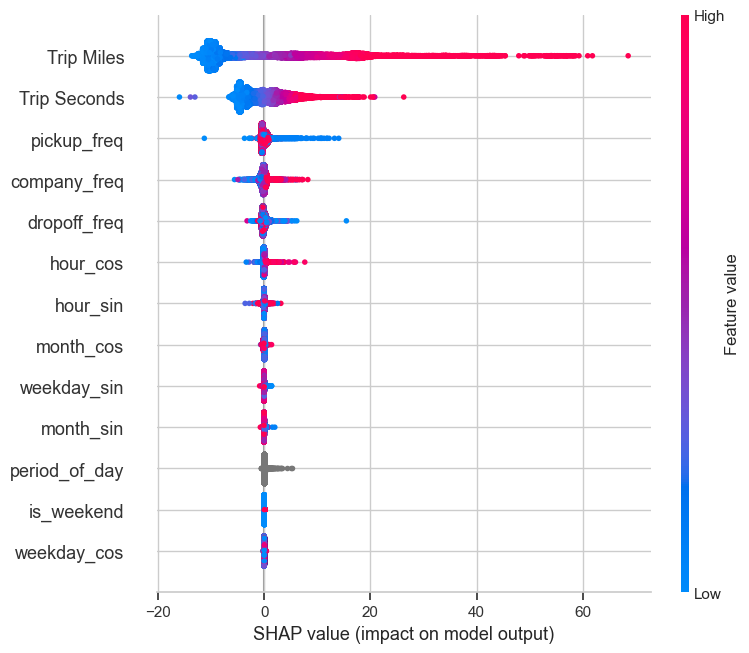

In [122]:
shap.summary_plot(shap_values, X_test_sample,) 

INTERPRÉTATION DU GRAPHIQUE SHAP

Ce graphique montre l'importance et l'impact des différentes variables sur les prédictions 
du modèle. L'axe vertical présente les variables ordonnées par importance décroissante. 
L'axe horizontal représente la valeur SHAP, c'est-à-dire l'impact de chaque variable sur 
la prédiction. La couleur indique la valeur de la variable (rouge = haute, bleu = basse).

Trip Miles apparaît comme la variable la plus importante du modèle. On observe que les 
valeurs élevées (points rouges) génèrent un impact très positif sur la prédiction, tandis 
que les valeurs faibles (points bleus) ont un impact proche de zéro. Cela signifie que 
plus le trajet est long, plus la prédiction augmente fortement, ce qui est cohérent avec 
une modélisation de tarification de courses.

Trip Seconds constitue la deuxième variable la plus importante avec un pattern similaire. 
Les trajets plus longs en durée augmentent également la prédiction. La relation logique 
entre Trip Miles et Trip Seconds confirme la cohérence du modèle.

Les variables de fréquence (pickup_freq, company_freq, dropoff_freq) ont un impact 
significatif mais plus modéré. Les hautes fréquences (points rouges) ont tendance à 
augmenter la prédiction. Ces variables capturent probablement l'effet des zones ou 
compagnies populaires sur le prix des courses.

Les variables temporelles encodées de manière cyclique (hour_cos, hour_sin, month_cos, 
weekday_sin, month_sin) présentent un impact plus dispersé et modéré. Elles permettent 
au modèle de capturer les variations liées aux heures de pointe et à la saisonnalité.

Enfin, period_of_day, is_weekend et weekday_cos montrent un impact minimal, indiquant 
qu'elles sont moins discriminantes pour la prédiction finale du modèle.

En conclusion, le modèle se base principalement sur la distance et la durée du trajet 
pour effectuer ses prédictions, ce qui est parfaitement cohérent pour un modèle de 
tarification de courses de taxi ou VTC.

## <span style="color:#1e90ff;">Modélisation de Fare avec le modèle TabNet </span>

TabNet est une architecture d'apprentissage profond (deep learning) spécifiquement conçue pour les données tabulaires. Les données tabulaires sont des informations structurées en lignes et en colonnes, telles que celles que l'on trouve dans les feuilles de calcul, les bases de données relationnelles ou les fichiers CSV. Introduit initialement par des chercheurs de Google, TabNet se distingue par son approche novatrice qui s'inspire des mécanismes d'attention utilisés avec succès dans le traitement du langage naturel et la vision par ordinateur, mais adaptée aux défis uniques des données tabulaires.

Contrairement à de nombreux modèles d'apprentissage profond qui excellent sur des données non structurées (images, texte, audio), les données tabulaires présentent souvent des caractéristiques hétérogènes (numériques, catégorielles) et des interactions complexes qui peuvent être difficiles à capturer. TabNet a été développé pour relever ces défis, en offrant à la fois une haute performance prédictive et une meilleure interprétabilité par rapport aux méthodes de type "boîte noire".

L'innovation majeure de TabNet réside dans son utilisation de l'attention séquentielle. Plutôt que d'utiliser toutes les caractéristiques (colonnes) simultanément à chaque étape de traitement, TabNet effectue une sélection séquentielle et dynamique des caractéristiques les plus informatives pour la tâche en cours (classification ou régression). Ce processus se déroule en plusieurs étapes de décision (decision steps) :
- À chaque étape, un mécanisme d'attention, appelé Attentive Transformer, apprend à attribuer des poids d'importance aux différentes caractéristiques.
- Seules les caractéristiques jugées les plus pertinentes à cette étape spécifique sont sélectionnées et traitées par un Feature Transformer.
- Les caractéristiques déjà utilisées lors des étapes précédentes peuvent être "masquées" ou moins pondérées pour encourager le modèle à explorer de nouvelles informations à chaque nouvelle étape.

In [ ]:
============================== stop ==============================

SyntaxError: invalid syntax (1893734894.py, line 1)

In [ ]:
features = [
    'Trip Seconds',
    'Trip Miles',
    'Pickup Community Area',
    'Dropoff Community Area',
    #'start_hour',     
    "hour_sin",
    "hour_cos",
    #"start_weekday",
    "weekday_sin",
    'weekday_cos', 
    #'start_month', 
    "month_sin", 
    "month_cos",
    'is_weekend',  # deja encodder 
    #'is_night'
    'period_of_day',
    # 'payment_freq',
    #'company_freq',
    "Company_clean"
    #'pickup_freq',
    #'dropoff_freq'
]

In [ ]:
X = df[features]
y = df["Fare"]
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [ ]:
categorical_cols = ["Pickup Community Area", "Dropoff Community Area", "period_of_day", "Company_clean"]

In [ ]:
# Encodage des variables catégorielles avec LabelEncoder (obligatoire pour TabNet)
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Cat_idxs et cat_dims pour TabNet
cat_idxs = [X_train.columns.get_loc(col) for col in categorical_cols]
cat_dims = [len(label_encoders[col].classes_) for col in categorical_cols]

In [ ]:
++++++++++++++++++++++++++++++++++++++++++++++++++++++STOP  NG ++++++++++++++++++++++++++++++

In [ ]:
# Initialisation du modèle
tabnet = TabNetRegressor(cat_idxs=cat_idxs, cat_dims=cat_dims, cat_emb_dim=8)

# Entraînement
tabnet.fit(
    X_train=X_train.values, y_train=y_train.values.reshape(-1,1),
    eval_set=[(X_train.values, y_train.values.reshape(-1,1)),
              (X_test.values, y_test.values.reshape(-1,1))],
    eval_name=['train', 'valid'],
    eval_metric=['rmse', 'mae'],
    max_epochs=100,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

c:\Users\maserati\Desktop\Mosef_2025\projet_ml_jb_alpha_rayane\Predicting_Airline_Ticket_Prices\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 22.62886| train_rmse: 4.49108 | train_mae: 1.78518 | valid_rmse: 4.48269 | valid_mae: 1.7839  |  0:09:49s
epoch 1  | loss: 19.87801| train_rmse: 4.39339 | train_mae: 1.71154 | valid_rmse: 4.37941 | valid_mae: 1.71034 |  0:19:32s
epoch 2  | loss: 18.8957 | train_rmse: 4.29886 | train_mae: 1.60436 | valid_rmse: 4.28584 | valid_mae: 1.60228 |  0:29:13s
epoch 3  | loss: 18.60298| train_rmse: 4.21331 | train_mae: 1.61692 | valid_rmse: 4.19179 | valid_mae: 1.61425 |  0:38:55s
epoch 4  | loss: 18.3184 | train_rmse: 4.23231 | train_mae: 1.6208  | valid_rmse: 4.21845 | valid_mae: 1.61878 |  0:49:06s
epoch 5  | loss: 18.20096| train_rmse: 4.25316 | train_mae: 1.56222 | valid_rmse: 4.23841 | valid_mae: 1.56065 |  0:58:32s
epoch 6  | loss: 18.10612| train_rmse: 4.3229  | train_mae: 2.20491 | valid_rmse: 4.30769 | valid_mae: 2.20227 |  1:07:57s
epoch 7  | loss: 18.01973| train_rmse: 4.20099 | train_mae: 1.66688 | valid_rmse: 4.18526 | valid_mae: 1.66525 |  1:17:22s
epoch 8  | loss:

c:\Users\maserati\Desktop\Mosef_2025\projet_ml_jb_alpha_rayane\Predicting_Airline_Ticket_Prices\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Le modèle TabNet a été entraîné avec un mécanisme d'early stopping qui surveille la 
performance sur l'ensemble de validation. L'entraînement s'est arrêté automatiquement 
à l'epoch 72, car aucune amélioration du MAE de validation n'a été observée pendant 
20 epochs consécutifs (patience=20). La meilleure performance a été atteinte à l'epoch 52 
avec un MAE de validation de 1.46993, ce qui représente l'erreur absolue moyenne la plus 
faible sur l'ensemble de test. 

On observe une forte instabilité des métriques RMSE entre 
les epochs (variant de 4.07 à 13.13), ce qui suggère des difficultés de convergence ou 
la présence de valeurs aberrantes dans les données. Le temps d'entraînement total a été 
d'environ 11 heures et 24 minutes pour 72 epochs, avec une durée moyenne d'environ 
9-10 minutes par epoch.

In [ ]:
# save tabnet model
saving_path_name = "./tabnet_model_test_1"
saved_filepath = tabnet.save_model(saving_path_name)

Successfully saved model at ./tabnet_model_test_1.zip


In [ ]:
# ===== PREDICTIONS TEST =====
preds = tabnet.predict(X_test.values)
y_true = y_test.values

# MSE, RMSE, MAE, R2
mse = mean_squared_error(y_true, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, preds)
r2 = r2_score(y_true, preds)

print("===== TABNET SCORE (TEST) =====")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

# Meilleur score de validation trouvé pendant l'entraînement
print("BEST VALID METRIC :", tabnet.best_cost)


===== TABNET SCORE (TEST) =====
MAE : 1.4699305121979387
RMSE: 5.190176190262465
R²  : 0.9024984802782751
BEST VALID METRIC : 1.4699305121979387


### Plot prédictions vs valeurs réelles

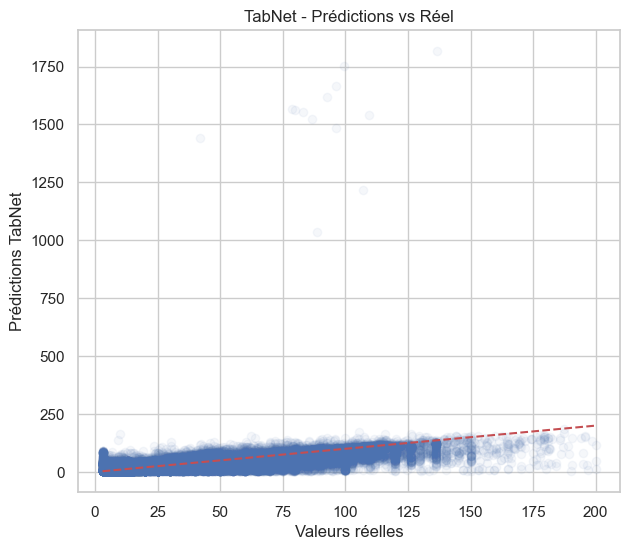

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(y_true, preds, alpha=0.05)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions TabNet")
plt.title("TabNet - Prédictions vs Réel")
plt.show()


### Features Importance 

In [ ]:
pd.set_option("display.float_format", "{:.6f}".format)

fi = tabnet.feature_importances_
pd.DataFrame({"feature": X.columns, "importance": fi}).sort_values("importance", ascending=False)


,feature,importance
1,Trip Miles,0.872088
0,Trip Seconds,0.097522
3,Dropoff Community Area,0.030379
12,Company_clean,0.000011
2,Pickup Community Area,0.000000
4,hour_sin,0.000000
5,hour_cos,0.000000
7,weekday_cos,0.000000
6,weekday_sin,0.000000
8,month_sin,0.000000


### Masks : Explicabilité locale (par couche d'attention)

In [ ]:
explain_matrix, masks = tabnet.explain(X_test.values)

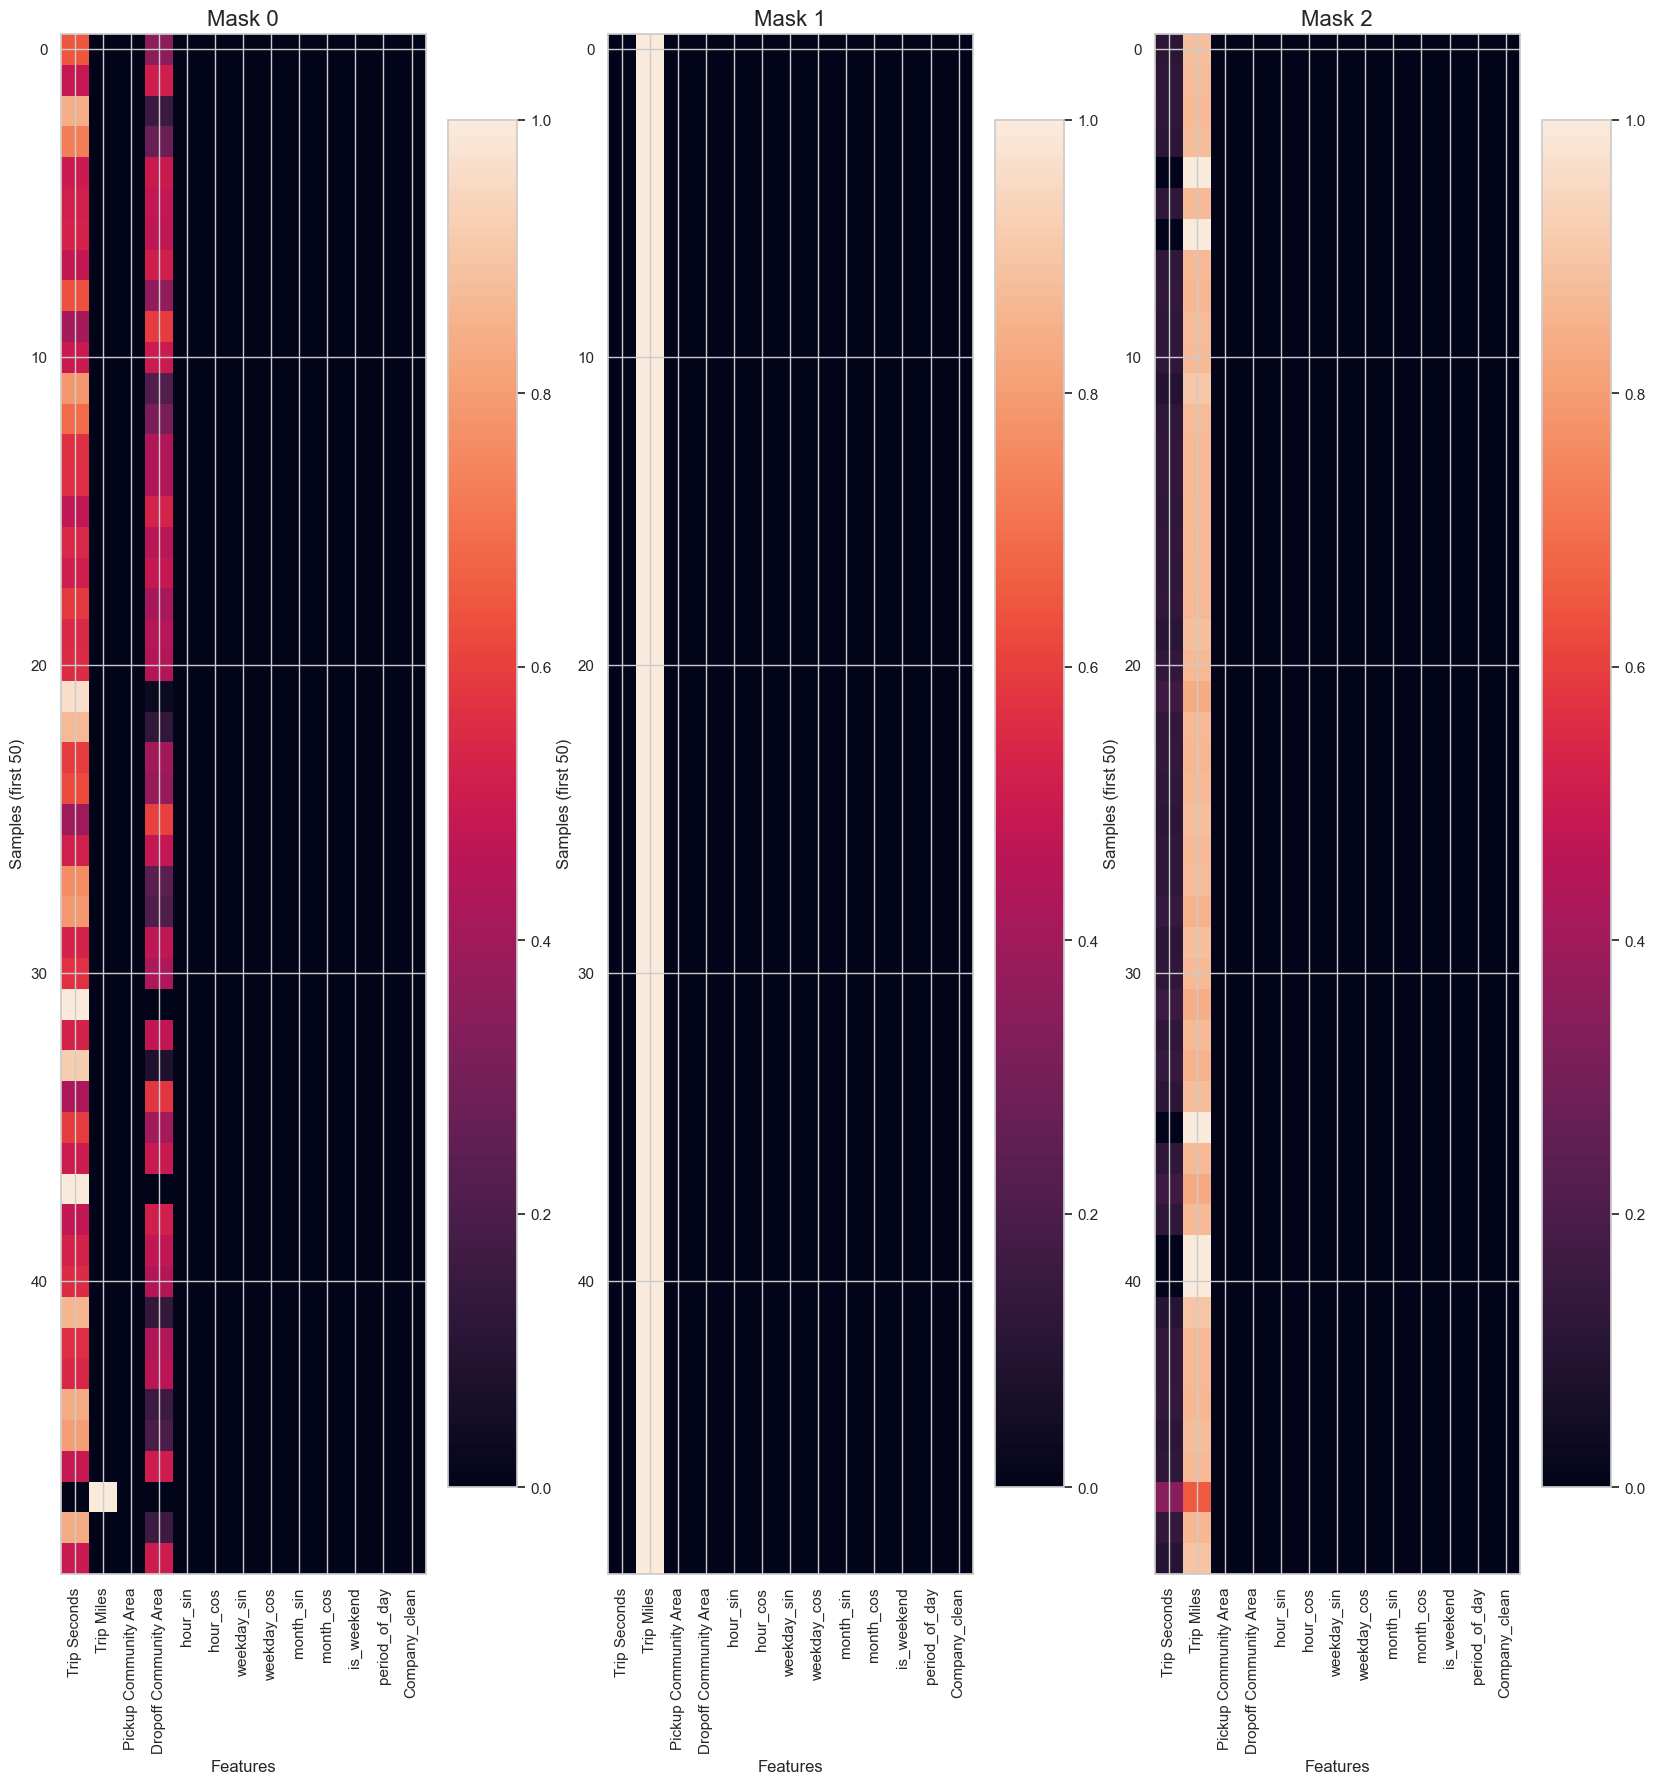

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = list(X.columns)

fig, axs = plt.subplots(1, 3, figsize=(20, 20))

for i in range(3):
    im = axs[i].imshow(masks[i][:50], aspect='auto')
    axs[i].set_title(f"Mask {i}", fontsize=16)
    axs[i].set_xlabel("Features")
    axs[i].set_ylabel("Samples (first 50)")
    axs[i].set_xticks(np.arange(len(feature_names)))
    axs[i].set_xticklabels(feature_names, rotation=90)
    fig.colorbar(im, ax=axs[i])


Masque 0 : Première étape (exploration initiale)
Le premier masque d’attention montre une répartition relativement large de l’attention, avec certaines features dominant nettement. Les variables les plus souvent sélectionnées sont Trip Seconds, Trip Miles, Pickup Community Area, Dropoff Community Area. Cela indique que TabNet utilise cette étape pour capter les signaux les plus évidents et structurants du prix de la course, tels que la durée, la distance, les zones de départ et d’arrivée. Cette étape correspond donc à une phase d’exploration initiale, permettant au modèle de se baser sur des informations fortes dès le début.

Masque 1 : Deuxième étape (raffinement)
Le deuxième masque présente une attention très concentrée sur une seule feature : Trip Miles. Cette forte focalisation suggère que TabNet cherche à expliquer l’essentiel de l’erreur résiduelle après la première étape. La concentration sur cette variable est typique lorsque celle-ci est très prédictive, potentiellement non linéaire ou en interaction avec d’autres features. Cette étape illustre la capacité de TabNet à raffiner sa décision en mettant l’accent sur la variable la plus informative pour corriger les écarts de prédiction initiaux.

Masque 2 : Troisième étape (affinage final)
Le dernier masque montre un retour à une attention particuliere sur Trip Seconds et Trip Miles. La récurrence de ces features souligne leur rôle stable et central dans le calcul du prix de la course et illustre la stratégie de TabNet consistant à combiner exploration initiale, concentration sur les variables clés, puis affinage final.

<h1 style="color:#ff4d4d; font-weight:bold; text-align:center;">
Résultat
</h1>


<h1 style="color:#ff4d4d; font-weight:bold; text-align:center;">
Conclusion
</h1>
